In [1]:
# @title Importar Bibliotecas

!pip install pycountry

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import joblib
import os
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve


ficheiro = "CPP_Transfer_Dataset.xlsx"

try:
  df = pd.read_excel(ficheiro)
  print(f"{ficheiro} carregado com sucesso!")

except FileNotFoundError:
  from google.colab import files
  uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 70.0 MB/s eta 0:00:00
CPP_Transfer_Dataset.xlsx carregado com sucesso!


In [2]:
# @title Criação de DataFrame
df_transfers = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="Transfers")
df_reservations = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="Reservations")
df_apartments = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="Apartments")
df_new_reservations = pd.read_excel("CPP_Transfer_Dataset.xlsx",sheet_name="NewReservations")

In [3]:
# @title Função analise_nulos

def analise_nulos(tabelas):
    tabelas_com_nulos = {}

    for nome, tabela in tabelas.items():
        nulos = tabela.isnull().sum()
        nulos = nulos[nulos > 0]
        if not nulos.empty:
            tabelas_com_nulos[nome] = nulos

    n_graficos = len(tabelas_com_nulos)

    if n_graficos > 0:
        fig, axes = plt.subplots(nrows=1, ncols=n_graficos, figsize=(5 * n_graficos, 4))


        if n_graficos == 1:
            axes = [axes]

        for ax, (nome, nulos) in zip(axes, tabelas_com_nulos.items()):
            sns.barplot(x=nulos.index, y=nulos.values, hue=nulos.index, palette="mako", legend=False, ax=ax)
            ax.set_title(f'Nulos - {nome.upper()}')
            ax.set_ylabel('Nº de Nulos')
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()


    for nome in tabelas.keys():
        if nome not in tabelas_com_nulos:
            print(f"✅ {nome.upper()}: Não tem valores nulos!")

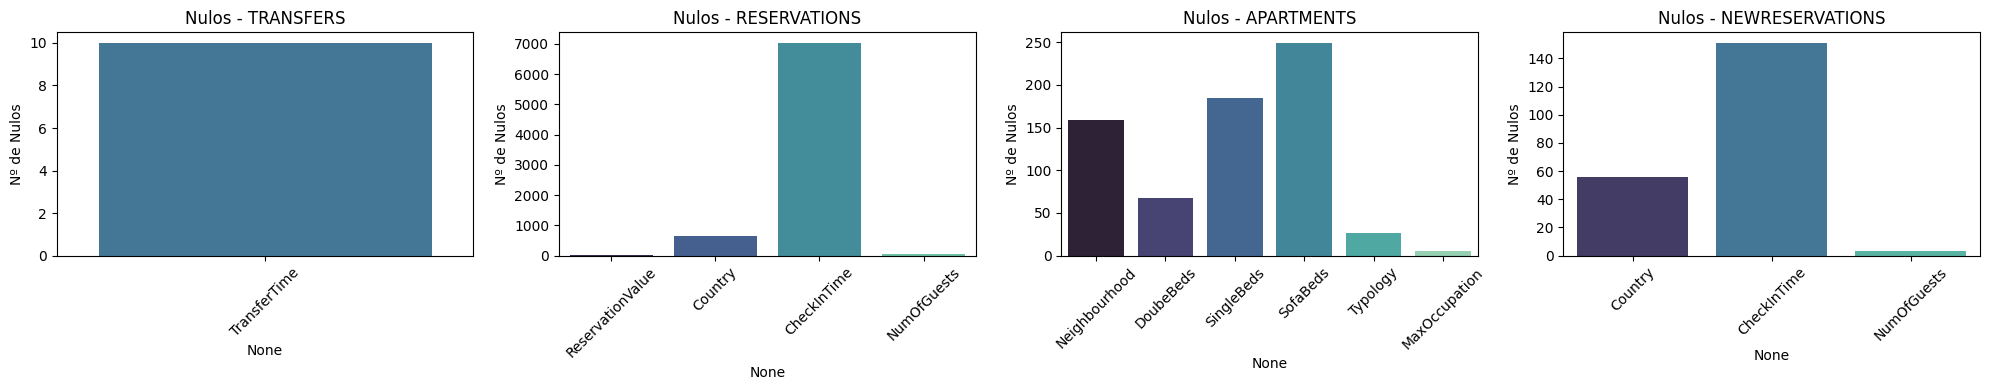

In [4]:
# @title Gráfico de nulos
minhas_tabelas = {
    'Transfers': df_transfers,
    'Reservations': df_reservations,
    'Apartments': df_apartments,
    'NewReservations': df_new_reservations
}

analise_nulos(minhas_tabelas)

In [5]:
# @title Formatação df_transfers

#Implementação da Variável Target na DF das Reservas
df_reservations["Tem_Transfer"] = df_reservations["ReservationId"].apply(lambda x: 1 if x in df_transfers["ReservationId"].values else 0)

percentagem_conversao = df_reservations["Tem_Transfer"].value_counts(normalize=True) * 100
print("Distribuição da nossa Variável Target (HasTransfer):\n")
print(percentagem_conversao)


Distribuição da nossa Variável Target (HasTransfer):

Tem_Transfer
0    92.445503
1     7.554497
Name: proportion, dtype: float64


In [6]:
# @title Modelação e Desenvolvimento de Funções do df_reservation_clean [LenOfStay, OriginOta, ReservationValue]

def cap_outliers(df, coluna, percentil=None, limite_fixo=None):
    df_limpo = df.copy()

    if limite_fixo is not None:
      valor_corte = limite_fixo
    elif percentil is not None:
      valor_corte = df[coluna].quantile(percentil)
    else:
      raise ValueError("Pelo menos um dos parâmetros deve ser fornecido: limite_fixo ou percentil.")

    df_limpo[coluna] = df_limpo[coluna].clip(upper=valor_corte)

    print(f"✅ Cap aplicado na coluna '{coluna}'! Valores acima de {valor_corte:.2f} foram cortados.")

    return df_limpo


#Desenvolvimento de uma função: originOta_clean
def originOta_clean(df, coluna, substituicoes, categorias_principais, nome_outros="Outros"):

    df_limpo = df.copy() # Segurança extra dentro da função

    # Substituir os nomes indesejados
    df_limpo[coluna] = df_limpo[coluna].replace(substituicoes)

    # Agrupar tudo o que não é principal em "Outros"
    df_limpo[coluna] = df_limpo[coluna].apply(lambda x: x if x in categorias_principais else nome_outros)

    return df_limpo

In [7]:
# @title df_reservation_clean [LenOfStay, OriginOta, ReservationValue] - continuação
df_reservations_clean = df_reservations.copy()

regras_substituicao = {'Booking - Unidade Preferida': 'Booking'}
canais_a_manter = ['Booking', 'Airbnb']

df_reservations_clean = originOta_clean(
    df=df_reservations_clean,
    coluna="OriginOTA",
    substituicoes=regras_substituicao,
    categorias_principais=canais_a_manter
)

print("Contagem das categorias finais:")
print(df_reservations_clean["OriginOTA"].value_counts())

Contagem das categorias finais:
OriginOTA
Booking    13896
Airbnb      7608
Outros      1158
Name: count, dtype: int64


In [8]:
# @title df_reservation_clean [LenOfStay, OriginOta, ReservationValue] - continuação
colunas_para_cortar = ["LenOfStay", "ReservationValue"]

for coluna in colunas_para_cortar:
    df_reservations_clean = cap_outliers(df_reservations_clean, coluna=coluna, percentil=0.99)

linhas_antes = len(df_reservations_clean)
df_reservations_clean = df_reservations_clean[df_reservations_clean['ReservationValue'] > 0]

linhas_depois = len(df_reservations_clean)
linhas_apagadas = linhas_antes - linhas_depois

print(f"✅ Limpeza concluída! Foram apagadas {linhas_apagadas} linhas.")

✅ Cap aplicado na coluna 'LenOfStay'! Valores acima de 10.00 foram cortados.
✅ Cap aplicado na coluna 'ReservationValue'! Valores acima de 3372.77 foram cortados.
✅ Limpeza concluída! Foram apagadas 39 linhas.


In [9]:
# @title df_reservation_clean [LenOfStay, OriginOta, ReservationValue] - continuação
def pipeline_reservas(df):
    df = df.copy()

    # ── Limpeza OTA ───────────────────────────────────────────────
    regras_substituicao   = {'Booking - Unidade Preferida': 'Booking'}
    canais_a_manter       = ['Booking', 'Airbnb']
    df = originOta_clean(
        df                    = df,
        coluna                = "OriginOTA",
        substituicoes         = regras_substituicao,
        categorias_principais = canais_a_manter
    )

    # ── Cap de outliers ───────────────────────────────────────────
    for coluna in ["LenOfStay", "ReservationValue"]:
        df = cap_outliers(df, coluna=coluna, percentil=0.99)

    # ── Remover reservas sem valor ────────────────────────────────
    linhas_antes  = len(df)
    df            = df[df['ReservationValue'] > 0]
    linhas_depois = len(df)
    print(f"Linhas removidas: {linhas_antes - linhas_depois}")

    return df

In [10]:
# @title Modelação e Desenvolvimento de Funções do df_reservation_clean [CheckInDate]

def process_reservation_date(df, coluna='ReservationDate', checkin_col='CheckInDate', drop_original=True):
    if coluna not in df.columns:
        print(f"⚠️ A coluna '{coluna}' já não existe ou já foi processada.")
        return df

    df[coluna] = pd.to_datetime(df[coluna], errors='coerce')

    # Antecedência em dias (só se CheckInDate ainda existir)
    if checkin_col in df.columns:
        df[checkin_col] = pd.to_datetime(df[checkin_col], errors='coerce')
        df['Antecedencia_dias'] = (df[checkin_col] - df[coluna]).dt.days
    else:
        print(f"⚠️ '{checkin_col}' não encontrada — Antecedencia_dias não calculada.")

    df['Reservation_Month']     = df[coluna].dt.month
    df['Reservation_DayOfWeek'] = df[coluna].dt.dayofweek

    if drop_original:
        if coluna in df.columns:
            df.drop(columns=[coluna], inplace=True)
        else:
            print(f"⚠️ A coluna '{coluna}' já não existe ou já foi dropada.")

    print(df[['Reservation_Month', 'Reservation_DayOfWeek']].head())
    return df

In [11]:
# @title df_reservation_clean [CheckInDate] - Continuação
df_reservations_clean = process_reservation_date(df_reservations_clean)  # 1º calcula Antecedencia_dias

   Reservation_Month  Reservation_DayOfWeek
0                  3                      4
1                  3                      4
2                  4                      0
3                  4                      1
4                  4                      1


In [12]:
# @title df_reservation_clean [CheckInDate] - Continuação

def checkin_features(df):
    df_limpo = df.copy()

    # 1. REDE DE SEGURANÇA: Se a coluna já não existir, devolve logo o df sem dar erro!
    if 'CheckInDate' not in df_limpo.columns:
        print("⚠️ A coluna 'CheckInDate' já não existe ou já foi processada.")
        return df_limpo

    # 2. Se a coluna existir, faz as transformações
    df_limpo['CheckInDate'] = pd.to_datetime(df_limpo['CheckInDate'])
    df_limpo['CheckIn_Month']       = df_limpo['CheckInDate'].dt.month
    df_limpo['CheckIn_DayOfWeek']   = df_limpo['CheckInDate'].dt.dayofweek
    df_limpo['CheckIn_IsWeekend']   = df_limpo['CheckInDate'].dt.dayofweek.isin([5, 6]).astype(int)
    df_limpo['CheckIn_IsHighSeason']= df_limpo['CheckInDate'].dt.month.isin([2, 3, 4, 5, 6]).astype(int)

    # (Lembrando: podes fazer o drop('CheckInDate') numa célula à parte)

    return df_limpo

In [13]:
df_reservations_clean = checkin_features(df_reservations_clean)
df_reservations_clean = df_reservations_clean.drop(columns=["CheckInDate"], errors= "ignore")

In [14]:
# @title Modelação e Desenvolvimento de Funções do df_reservation_clean [Country]

# Guardar original ANTES de qualquer transformação
df_reservations_clean['Country_original'] = df_reservations_clean['Country'].copy()

# Normalizar: strip de espaços + upper
df_reservations_clean['Country'] = df_reservations_clean['Country'].str.strip().str.upper()

# Mapeamento completo (original + typos encontrados)
country_map = {
    # França
    'FRANÇA': 'FR', 'FRANCE': 'FR',
    # Suíça
    'SUIÇA': 'CH', 'SUÍÇA': 'CH', 'SWITZERLAND': 'CH', 'SWITZERAND': 'CH', 'SWIZTERLAND': 'CH', 'SUIÇO': 'CH',
    # Rússia
    'RUSSIA': 'RU', 'RÚSSIA': 'RU',
    # Itália
    'ITÁLIA': 'IT',
    # Argentina
    'ARGENTINA': 'AR',
    # Coreia do Sul
    'COREIA DO SUL': 'KR', 'COREIA DO SOUTH': 'KR', 'SOUTH KOREA': 'KR', 'KOREA, SOUTH': 'KR',
    # Canadá
    'CANADÁ': 'CA', 'CANADA': 'CA',
    # Suécia
    'SUECIA': 'SE', 'SUÉCIA': 'SE', 'SWEDEN': 'SE',
    # Noruega
    'NORUEGA': 'NO', 'NORWAY': 'NO',
    # Dinamarca
    'DINAMARCA': 'DK', 'DENMARK': 'DK',
    # Finlândia
    'FINLANDIA': 'FI', 'FINLÂNDIA': 'FI', 'FINLAND': 'FI',
    # Hungria
    'HUNGRIA': 'HU', 'HUNGARY': 'HU',
    # Ucrânia
    'UCRANIA': 'UA', 'UCRÂNIA': 'UA', 'UKRAINE': 'UA',
    # Grécia
    'GRECIA': 'GR', 'GREECE': 'GR', 'GRÉCIA': 'GR',
    # Roménia
    'ROMANIA': 'RO', 'ROMENIA': 'RO',
    # Bulgária
    'BULGARIA': 'BG', 'BULGÁRIA': 'BG',
    # República Checa
    'REPUBLICA CHECA': 'CZ', 'CZECH REPUBLIC': 'CZ',
    # Eslováquia
    'ESLOVAQUIA': 'SK', 'SLOVAK REPUBLIC': 'SK', 'ESLAQUIA': 'SK',
    # Eslovénia
    'ESLOVENIA': 'SI',
    # Croácia
    'CROACIA': 'HR', 'CROATIA': 'HR',
    # Turquia
    'TURQUIA': 'TR',
    # México
    'MEXICO': 'MX', 'MÉXICO': 'MX',
    # Colômbia
    'COLOMBIA': 'CO', 'COLÔMBIA': 'CO',
    # Chile
    'CHILE': 'CL',
    # Peru
    'PERU': 'PE',
    # Uruguai
    'URUGUAI': 'UY', 'URUGUAY': 'UY',
    # Costa Rica
    'COSTA RICA': 'CR',
    # Índia
    'INDIA': 'IN',
    # Israel
    'ISRAEL': 'IL',
    # Indonésia
    'INDONESIA': 'ID',
    # Malásia
    'MALASIA': 'MY', 'MALAYSIA': 'MY', 'MALASYA': 'MY',
    # Singapura
    'SINGAPURA': 'SG', 'SINGAPORE': 'SG',
    # Taiwan
    'TAIWAN': 'TW',
    # Hong Kong
    'HONG KONG': 'HK', 'HONGKONG': 'HK',
    # Macau
    'MACAU': 'MO',
    # Japão
    'JAPAO': 'JP',
    # África do Sul
    'AFRICA DO SUL': 'ZA', 'SOUTH AFRICA': 'ZA',
    # Angola
    'ANGOLA': 'AO',
    # Moçambique
    'MOÇAMBIQUE': 'MZ',
    # Marrocos
    'MARROCOS': 'MA',
    # Bélgica
    'BELGICA': 'BE', 'BÉLGICA': 'BE',
    # Luxemburgo
    'LUXEMBURGO': 'LU', 'LUXEMBOURG': 'LU',
    # Lituânia
    'LITUÂNIA': 'LT', 'LITHUANIA': 'LT', 'LITUANIA': 'LT',
    # Letónia
    'LETONIA': 'LV', 'LETÓNIA': 'LV', 'LETÔNIA': 'LV',
    # Estónia
    'ESTONIA': 'EE',
    # Emirados Árabes
    'EMIRADOS ARABES UNIDOS': 'AE', 'DUBAI': 'AE',
    # Polónia
    'POLÓNIA': 'PL', 'POLÔNIA': 'PL',
    # Nova Zelândia
    'NOVA ZELÂNDIA': 'NZ', 'NOVA ZELANDIA': 'NZ', 'NEW ZELAND': 'NZ',
    # Austrália
    'AUSTRÁLIA': 'AU',
    # Filipinas
    'FILIPINAS': 'PH',
    # Vietname
    'VIETNÃ': 'VN', 'VIETNAME': 'VN',
    # Guatemala
    'GUATEMALA': 'GT',
    # Panama
    'PANAMA': 'PA',
    # Equador
    'ECUADOR': 'EC', 'EQUADOR': 'EC',
    # Venezuela
    'VENEZUELA': 'VE',
    # Porto Rico
    'PORTO RICO': 'PR',
    # Egipto
    'EGIPTO': 'EG',
    # Líbano
    'LIBANO': 'LB', 'LÍBANO': 'LB',
    # Belarus
    'BELARUS': 'BY',
    # Geórgia
    'GEORGIA': 'GE',
    # Argélia
    'ARGELIA': 'DZ',
    # Tailândia
    'TAILANDIA': 'TH',
    # Holanda
    'HOLANDA': 'NL', 'HOANDA': 'NL',
    # Quénia
    'QUENIA': 'KE',
    # Irlanda
    'IRLANDA': 'IE',
    # República Dominicana
    'REPUBLICA DOMINICANA': 'DO',
    # Guiana Francesa
    'GUIANA FRANCESA': 'GF',
    # Espanha (typo)
    'SAPIN': 'ES',
    # Lixo — cidades → Unknown
    'AMADORA': 'Unknown',
    'BILBAO': 'Unknown',
    # Aliases ISO
    'BE': 'BE', 'KR': 'KR',
}

df_reservations_clean['Country'] = df_reservations_clean['Country'].replace(country_map)

# Países europeus para categorias "outros"
EUROPA = {
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR','DE','GR','HU','IE',
    'IT','LV','LT','LU','MT','NL','PL','PT','RO','SK','SI','ES','SE','GB',
    'NO','CH','IS','LI','AL','BA','ME','MK','RS','MD','UA','BY','RU','GE',
    'AM','AZ','TR','XK'
}

def corrigir_pais(nome):
    if pd.isna(nome) or nome == 'Unknown':
        return 'Unknown'
    # Lixo: emails, telefones, strings longas
    if '@' in str(nome) or str(nome).startswith('+') or len(str(nome)) > 50:
        return 'Unknown'
    # Já é ISO válido
    if pycountry.countries.get(alpha_2=str(nome).upper()):
        return str(nome).upper()
    # Tentar fuzzy match
    try:
        resultado = pycountry.countries.search_fuzzy(nome)
        return resultado[0].alpha_2
    except LookupError:
        return 'Unknown'

df_reservations_clean['Country'] = df_reservations_clean['Country'].apply(corrigir_pais)

# Categorizar os Unknown com base no valor original
def categorizar_unknown(row):
    if row['Country'] != 'Unknown':
        return row['Country']
    original = str(row['Country_original']).strip().upper()
    # Tenta inferir o país do original
    try:
        resultado = pycountry.countries.search_fuzzy(original)
        iso = resultado[0].alpha_2
        if iso in EUROPA:
            return 'OUTROS_EUROPA'
        else:
            return 'OUTROS_MUNDO'
    except Exception:
        return 'OUTROS_MUNDO'  # lixo total vai para outros_mundo

df_reservations_clean['Country'] = df_reservations_clean.apply(categorizar_unknown, axis=1)

# Limpar coluna auxiliar
df_reservations_clean.drop(columns=['Country_original'], inplace=True)

# Relatório final
def is_iso2(code):
    return pycountry.countries.get(alpha_2=str(code).upper()) is not None

print(f"Países únicos após correção final: {df_reservations_clean['Country'].nunique()}")
print(f"OUTROS_EUROPA: {(df_reservations_clean['Country'] == 'OUTROS_EUROPA').sum()}")
print(f"OUTROS_MUNDO: {(df_reservations_clean['Country'] == 'OUTROS_MUNDO').sum()}")
print(f"Unknown restantes: {(df_reservations_clean['Country'] == 'Unknown').sum()}")
display(df_reservations_clean['Country'].value_counts())

restantes = df_reservations_clean[
    ~df_reservations_clean['Country'].apply(
        lambda x: x in ['Unknown', 'OUTROS_EUROPA', 'OUTROS_MUNDO'] or is_iso2(x)
    )
]['Country'].value_counts()
print(f"\nAinda por corrigir: {len(restantes)}")
print(restantes)

Países únicos após correção final: 131
OUTROS_EUROPA: 0
OUTROS_MUNDO: 648
Unknown restantes: 0


,count
Country,
ES,4019
FR,2404
PT,2097
GB,1999
DE,1596
...,...
BS,1
BH,1
SV,1



Ainda por corrigir: 0
Series([], Name: count, dtype: int64)


In [15]:
# @title df_reservation_clean [Country] - Continuação

# Threshold — países com menos de X registos são agrupados
THRESHOLD = 250 # ajusta conforme quiseres

# Contar registos por país
country_counts = df_reservations_clean['Country'].value_counts()

# Países com poucos registos (excluindo já as categorias "outros" e Unknown)
low_rep = country_counts[
    (country_counts < THRESHOLD) &
    (~country_counts.index.isin(['OUTROS_EUROPA', 'OUTROS_MUNDO', 'Unknown']))
].index.tolist()

print(f"Países com menos de {THRESHOLD} registos: {len(low_rep)}")
print(low_rep)

# Reagrupar
def reagrupar_pais(country):
    if country not in low_rep:
        return country
    if country in EUROPA:
        return 'OUTROS_EUROPA'
    else:
        return 'OUTROS_MUNDO'

df_reservations_clean['Country'] = df_reservations_clean['Country'].apply(reagrupar_pais)

# Relatório final
print(f"\nDistribuição final:")
display(df_reservations_clean['Country'].value_counts())
print(f"\nTotal categorias: {df_reservations_clean['Country'].nunique()}")

Países com menos de 250 registos: 115
['KR', 'AT', 'AR', 'CN', 'SE', 'UA', 'RO', 'HU', 'IL', 'CZ', 'DK', 'FI', 'ZA', 'NO', 'GR', 'LU', 'RU', 'TW', 'CO', 'SK', 'BG', 'HK', 'MX', 'JP', 'TR', 'HR', 'EE', 'NZ', 'LV', 'LT', 'IN', 'SG', 'CL', 'RS', 'SI', 'AO', 'AE', 'MA', 'BY', 'MY', 'UY', 'MZ', 'CR', 'PE', 'ID', 'TH', 'MO', 'LB', 'MT', 'GE', 'VE', 'MK', 'PH', 'EG', 'GT', 'GI', 'PA', 'CV', 'KZ', 'DO', 'EC', 'JE', 'PR', 'IS', 'DZ', 'AL', 'SA', 'VN', 'GP', 'TN', 'AM', 'BO', 'LK', 'BA', 'QA', 'AW', 'MG', 'MD', 'JO', 'SM', 'GF', 'CI', 'KE', 'IR', 'PS', 'CY', 'SN', 'KW', 'PY', 'KY', 'SC', 'NA', 'GA', 'TZ', 'RE', 'LI', 'GD', 'PK', 'CW', 'BD', 'LA', 'IM', 'TF', 'NC', 'MM', 'AD', 'IQ', 'HN', 'CM', 'BZ', 'BS', 'BH', 'SV', 'NI', 'NG']

Distribuição final:


,count
Country,
ES,4019
FR,2404
PT,2097
OUTROS_MUNDO,2060
GB,1999
DE,1596
OUTROS_EUROPA,1582
IT,1465
BR,1224



Total categorias: 17


In [16]:
# @title Modelação e Desenvolvimento de Funções do df_reservation_clean [CheckInTime]

def process_checkin_time(df, coluna='CheckInTime', drop_original=True):
    # 1. Boa prática: criar cópia
    df_limpo = df.copy()

    # 2. Rede de segurança CORRIGIDA (verifica a coluna certa)
    if coluna not in df_limpo.columns:
        print(f"⚠️ A coluna '{coluna}' já não existe ou já foi processada.")
        return df_limpo

    df_limpo[coluna] = pd.to_datetime(df_limpo[coluna], errors='coerce')

    def categorizar_turno(hora):
        if pd.isna(hora):
            return 'Desconhecido'
        hora = int(hora)
        if 6 <= hora < 14:
            return 'Manha'
        elif 14 <= hora < 22:
            return 'Tarde'
        else:
            return 'Noite'

    df_limpo['Turno_CheckIn'] = df_limpo[coluna].dt.hour.apply(categorizar_turno)

    # 3. Fazer o drop se solicitado
    if drop_original:
        df_limpo.drop(columns=[coluna], inplace=True)

    print(df_limpo['Turno_CheckIn'].value_counts())

    return df_limpo

In [17]:
# @title df_reservation_clean [CheckInTime] - Continuação
df_reservations_clean = process_checkin_time(df_reservations_clean)

Turno_CheckIn
Tarde           9322
Desconhecido    7002
Manha           4949
Noite           1350
Name: count, dtype: int64


/tmp/ipykernel_8228/3891767212.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_limpo[coluna] = pd.to_datetime(df_limpo[coluna], errors='coerce')


In [18]:
df_reservations_clean

,ReservationId,ApartmentId,LenOfStay,OriginOTA,ReservationValue,Country,NumOfGuests,Tem_Transfer,Antecedencia_dias,Reservation_Month,Reservation_DayOfWeek,CheckIn_Month,CheckIn_DayOfWeek,CheckIn_IsWeekend,CheckIn_IsHighSeason,Turno_CheckIn
0,54351,528,3,Booking,576.720,GB,2.0,1,354,3,4,3,1,0,1,Desconhecido
1,54372,299,5,Booking,993.600,OUTROS_MUNDO,4.0,1,315,3,4,2,4,0,1,Desconhecido
2,57253,351,3,Airbnb,1044.000,OUTROS_MUNDO,6.0,1,324,4,0,3,2,0,1,Desconhecido
3,57268,500,7,Booking,1784.160,US,2.0,1,295,4,1,2,2,0,1,Desconhecido
4,57311,20,3,Booking,790.560,NL,6.0,1,343,4,1,4,1,0,1,Desconhecido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22657,1879080749,971,2,Airbnb,475.200,FR,3.0,0,0,12,5,12,5,1,0,Tarde
22658,1879080751,324,5,Outros,1255.920,FR,2.0,0,0,12,5,12,5,1,0,Desconhecido
22659,1879080758,14,2,Booking,980.448,PT,3.0,0,0,12,5,12,5,1,0,Tarde
22660,1879080767,1196,2,Airbnb,465.600,PT,4.0,0,0,12,5,12,5,1,0,Tarde


In [19]:
# @title df_reservation_clean [CheckInTime]
df_reservations_clean = df_reservations_clean[df_reservations_clean["Antecedencia_dias"] >= 0]
df_reservations_clean = cap_outliers(df_reservations_clean, coluna="Antecedencia_dias", percentil=0.99)

✅ Cap aplicado na coluna 'Antecedencia_dias'! Valores acima de 255.00 foram cortados.


In [20]:
df_reservations_clean["NumOfGuests"].info()

<class 'pandas.core.series.Series'>
Index: 22602 entries, 0 to 22661
Series name: NumOfGuests
Non-Null Count  Dtype  
--------------  -----  
22570 non-null  float64
dtypes: float64(1)
memory usage: 353.2 KB


In [21]:
df_reservations_clean = df_reservations_clean[df_reservations_clean["NumOfGuests"] >= 0]

In [22]:
df_reservations_clean

,ReservationId,ApartmentId,LenOfStay,OriginOTA,ReservationValue,Country,NumOfGuests,Tem_Transfer,Antecedencia_dias,Reservation_Month,Reservation_DayOfWeek,CheckIn_Month,CheckIn_DayOfWeek,CheckIn_IsWeekend,CheckIn_IsHighSeason,Turno_CheckIn
0,54351,528,3,Booking,576.720,GB,2.0,1,255,3,4,3,1,0,1,Desconhecido
1,54372,299,5,Booking,993.600,OUTROS_MUNDO,4.0,1,255,3,4,2,4,0,1,Desconhecido
2,57253,351,3,Airbnb,1044.000,OUTROS_MUNDO,6.0,1,255,4,0,3,2,0,1,Desconhecido
3,57268,500,7,Booking,1784.160,US,2.0,1,255,4,1,2,2,0,1,Desconhecido
4,57311,20,3,Booking,790.560,NL,6.0,1,255,4,1,4,1,0,1,Desconhecido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22657,1879080749,971,2,Airbnb,475.200,FR,3.0,0,0,12,5,12,5,1,0,Tarde
22658,1879080751,324,5,Outros,1255.920,FR,2.0,0,0,12,5,12,5,1,0,Desconhecido
22659,1879080758,14,2,Booking,980.448,PT,3.0,0,0,12,5,12,5,1,0,Tarde
22660,1879080767,1196,2,Airbnb,465.600,PT,4.0,0,0,12,5,12,5,1,0,Tarde


## Adição da Limpeza do Apartments

In [23]:
# @title Carregar e Inspecionar Dados de Apartamentos
df = pd.read_excel('CPP_Transfer_Dataset.xlsx', sheet_name='Apartments')
print(f"Registos carregados: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Registos carregados: 607
Colunas: ['ApartmentId', 'Region', 'Neighbourhood', 'ApartmentHasElevator', 'DoubeBeds', 'SingleBeds', 'SofaBeds', 'Typology', 'MaxOccupation']

Missing values:
ApartmentId               0
Region                    0
Neighbourhood           159
ApartmentHasElevator      0
DoubeBeds                68
SingleBeds              184
SofaBeds                249
Typology                 26
MaxOccupation             5
dtype: int64


In [24]:
# @title Função clean_typology
def clean_typology(df):
    df = df.copy()
    df = df[df['Typology'] != 'Moradia'].reset_index(drop=True)
    df['Typology'] = df['Typology'].str.strip()
    df['Typology'] = df['Typology'].replace({'Studio': 'T0', 'studio': 'T0'})
    df['IsDuplex'] = df['Typology'].str.contains('Duplex', na=False).astype(int)
    df['TypologyNum'] = df['Typology'].str.extract(r'T(\d+)').astype(float)
    return df

In [25]:
# @title Limpeza e Análise da Tipologia (Passo 2)
df_apt = clean_typology(df)

print(f"Registos após Passo 2: {len(df_apt)}")
print(f"\nTypology após limpeza:\n{df_apt['Typology'].value_counts(dropna=False)}")
print(f"\nIsDuplex:\n{df_apt['IsDuplex'].value_counts()}")
print(f"\nTypologyNum:\n{df_apt['TypologyNum'].value_counts(dropna=False).sort_index()}")

Registos após Passo 2: 606

Typology após limpeza:
Typology
T2           208
T1           199
T3            73
T0            58
NaN           26
T4            18
T5             9
T1 Duplex      7
T2 Duplex      5
T3 Duplex      2
T6             1
Name: count, dtype: int64

IsDuplex:
IsDuplex
0    592
1     14
Name: count, dtype: int64

TypologyNum:
TypologyNum
0.0     58
1.0    206
2.0    213
3.0     75
4.0     18
5.0      9
6.0      1
NaN     26
Name: count, dtype: int64


In [26]:
# @title Função remove_invalid_apartments
def remove_invalid_apartments(df):
    df = df.copy()
    initial = len(df)

    calc_occ = (
        df['DoubeBeds'].fillna(0) * 2 +
        df['SingleBeds'].fillna(0) +
        df['SofaBeds'].fillna(0)
    )
    mask_caso1 = (
        (df['DoubeBeds'].fillna(0) == 0) &
        (df['SingleBeds'].fillna(0) == 0) &
        (df['SofaBeds'].fillna(0) == 0) &
        (df['MaxOccupation'].fillna(0) == 0)
    )
    mask_caso2 = (
        (df['DoubeBeds'].fillna(0) == 0) &
        (df['SingleBeds'].fillna(0) == 0) &
        (df['SofaBeds'].fillna(0) == 0) &
        (df['MaxOccupation'].fillna(0) > 0)
    )
    beds_known = (
        df['DoubeBeds'].notna() &
        df['SingleBeds'].notna() &
        df['MaxOccupation'].notna()
    )
    mask_caso3 = beds_known & (df['MaxOccupation'] < calc_occ)

    mask_remove = mask_caso1 | mask_caso2 | mask_caso3
    df = df[~mask_remove].reset_index(drop=True)
    print(f"Removidos: {initial - len(df)} | Restam: {len(df)}")
    return df

In [27]:
# @title Função clean_invalid_apartments
def clean_invalid_apartments(df):
    df = df.copy()

    calc_occ = (
        df['DoubeBeds'].fillna(0) * 2 +
        df['SingleBeds'].fillna(0) +
        df['SofaBeds'].fillna(0)
    )

    # Caso 1 e 2 — sem camas: imputar MaxOccupation com a mediana
    mask_sem_camas = (
        (df['DoubeBeds'].fillna(0) == 0) &
        (df['SingleBeds'].fillna(0) == 0) &
        (df['SofaBeds'].fillna(0) == 0)
    )
    mediana_occ = df.loc[~mask_sem_camas, 'MaxOccupation'].median()
    df.loc[mask_sem_camas, 'MaxOccupation'] = df.loc[mask_sem_camas, 'MaxOccupation'].fillna(mediana_occ)

    # Caso 3 — MaxOccupation inferior à soma das camas: corrigir com a soma calculada
    beds_known = (
        df['DoubeBeds'].notna() &
        df['SingleBeds'].notna() &
        df['MaxOccupation'].notna()
    )
    mask_caso3 = beds_known & (df['MaxOccupation'] < calc_occ)
    df.loc[mask_caso3, 'MaxOccupation'] = calc_occ[mask_caso3]

    print(f"Apartamentos corrigidos (sem camas): {mask_sem_camas.sum()}")
    print(f"Apartamentos corrigidos (occ < camas): {mask_caso3.sum()}")
    print(f"Total apartamentos: {len(df)}")

    return df

In [28]:
# @title Função impute_sofabeds
def impute_sofabeds(df):
    df = df.copy()
    df['SofaBeds'] = df['SofaBeds'].fillna(0)
    return df

In [29]:
# @title Função impute_typology_num
def impute_typology_num(df):
    df = df.copy()

    typo_by_maxocc = df.groupby('MaxOccupation')['TypologyNum'].median()
    typo_by_region = df.groupby('Region')['TypologyNum'].apply(
        lambda x: x.mode()[0] if not x.mode().empty else x.median()
    )

    def estimate(row):
        if pd.notna(row['TypologyNum']):
            return row['TypologyNum']
        if pd.notna(row['DoubeBeds']) and pd.notna(row['SingleBeds']):
            return float(row['DoubeBeds'] + np.ceil(row['SingleBeds'] / 2))
        if pd.notna(row['MaxOccupation']):
            return typo_by_maxocc.get(row['MaxOccupation'], np.nan)
        return typo_by_region.get(row['Region'], np.nan)

    df['TypologyNum'] = df.apply(estimate, axis=1)
    return df

In [30]:
# @title Função impute_beds_by_typology
def impute_beds_by_typology(df):
    df = df.copy()

    double_median = df.groupby('TypologyNum')['DoubeBeds'].median()
    single_median = df.groupby('TypologyNum')['SingleBeds'].median()

    df['DoubeBeds'] = df.apply(
        lambda r: double_median[r['TypologyNum']] if pd.isna(r['DoubeBeds']) else r['DoubeBeds'], axis=1
    )
    df['SingleBeds'] = df.apply(
        lambda r: single_median[r['TypologyNum']] if pd.isna(r['SingleBeds']) else r['SingleBeds'], axis=1
    )
    return df

In [31]:
# @title Limpeza e Imputação de Apartamentos (Passo 3)
df_apt = remove_invalid_apartments(df_apt)
df_apt = impute_sofabeds(df_apt)
df_apt = impute_typology_num(df_apt)
df_apt = impute_beds_by_typology(df_apt)

print(f"Registos após Passo 3: {len(df_apt)}")
print(f"\\nMissing values:\\n{df_apt.isnull().sum()}")

Removidos: 29 | Restam: 577
Registos após Passo 3: 577
\nMissing values:\nApartmentId               0
Region                    0
Neighbourhood           151
ApartmentHasElevator      0
DoubeBeds                 0
SingleBeds                0
SofaBeds                  0
Typology                  5
MaxOccupation             0
IsDuplex                  0
TypologyNum               0
dtype: int64


In [32]:
# @title Criação de Novas Variáveis de Camas
def create_new_variables(df):
    df = df.copy()
    # Contagem total de camas físicas
    df['TotalBeds'] = df['DoubeBeds'] + df['SingleBeds'] + df['SofaBeds']
    # Capacidade teórica em pessoas (SofaBeds x1 validado empiricamente)
    df['TotalCapacityFromBeds'] = df['DoubeBeds'] * 2 + df['SingleBeds'] + df['SofaBeds']
    return df

In [33]:
# @title Aplicação e Verificação de Novas Variáveis de Camas
df_apt = create_new_variables(df_apt)

print(f"Registos após Passo 4: {len(df_apt)}")
print(f"\nNovas variáveis:")
print(df_apt[['DoubeBeds','SingleBeds','SofaBeds',
              'TotalBeds','TotalCapacityFromBeds','MaxOccupation']].describe().round(2))

Registos após Passo 4: 577

Novas variáveis:
       DoubeBeds  SingleBeds  SofaBeds  TotalBeds  TotalCapacityFromBeds  \
count     577.00      577.00     577.0     577.00                 577.00   
mean        1.21        1.62       0.4       3.23                   4.44   
std         0.58        1.48       0.5       1.54                   1.87   
min         0.00        0.00       0.0       1.00                   1.00   
25%         1.00        0.00       0.0       2.00                   3.00   
50%         1.00        2.00       0.0       3.00                   4.00   
75%         1.00        2.00       1.0       4.00                   6.00   
max         4.00        8.00       2.0      10.00                  12.00   

       MaxOccupation  
count         577.00  
mean            4.29  
std             1.66  
min             1.00  
25%             3.00  
50%             4.00  
75%             5.00  
max            12.00  


In [34]:
# @title Criação do mapa do Metro por Region e respetiva Dummie (se com ou sem metro)
def create_transport_variables(df):
    df = df.copy()

    neighbourhood_map = {
        # Lisboa — com metro
        'Alfama':1, 'Castelo':1, 'Sé':1, 'Mouraria':1, 'Martim Moniz':1,
        'Baixa':1, 'Chiado':1, 'Bica':1, 'Cais do Sodré':1, 'Bairro Alto':1,
        'Principe Real':1, 'Rato':1, 'Mercês':1, 'Av. Novas':1, 'Saldanha':1,
        'Marquês de Pombal':1, 'Av. da Liberdade':1, 'Restauradores':1,
        'S. José':1, 'Graça':1, 'Beato':1, 'Intendente':1,
        'Almirante Reis':1, 'Benfica':1, 'Santa Marta':1, 'Olivais':1,
        # Lisboa — sem metro
        'Lapa':0, 'Estrela':0, 'Campo de Ourique':0, 'S. Bento':0,
        'Belém':0, 'Restelo':0, 'Madragoa':0, 'Santa Catarina':0,
        'Cascais':0, 'Ericeira':0, 'Lisboa':0,
        # Porto — com metro
        'Ribeira':1, 'Trindade':1, 'Boavista':1, 'Cedofeita':1,
        # Porto — sem metro
        'Foz':0, 'Porto':0,
        # Algarve — sem metro
        'Albufeira':0, 'Carrapateira':0, 'Lagoa':0,
        'Monte Gordo':0, 'Tavira':0, 'Vilamoura':0,
    }

    df['NearMetroOrTrain'] = df['Neighbourhood'].map(
        lambda x: neighbourhood_map.get(x, 0) if pd.notna(x) else np.nan
    )

    # Imputação missing por região:
    # Algarve e Ericeira → 0 (sem metro)
    # Porto → 1 (moda: 5 de 6 bairros conhecidos têm metro)
    impute_map = {'Algarve': 0, 'Ericeira': 0, 'Porto': 1}
    mask_missing = df['NearMetroOrTrain'].isna()
    df.loc[mask_missing, 'NearMetroOrTrain'] = df.loc[mask_missing, 'Region'].map(impute_map)

    return df

In [35]:
# @title Função drop_replaced_columns
def drop_replaced_columns(df):
    df = df.copy()
    # Neighbourhood → substituído por NearMetroOrTrain
    # Typology (texto) → substituído por TypologyNum + IsDuplex
    cols_to_drop = [c for c in ['Neighbourhood', 'Typology', 'NearAirport', 'OccupancyGap'] if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    return df

In [36]:
# @title Criação de Variáveis de Transporte e Limpeza de Colunas Redundantes
df_apt = create_transport_variables(df_apt)
df_apt = drop_replaced_columns(df_apt)

print(f"Registos após Passo 5: {len(df_apt)}")
print(f"\nColunas: {list(df_apt.columns)}")
print(f"\nMissing values:\n{df_apt.isnull().sum()}")
print(f"\nDistribuição NearMetroOrTrain:\n{df_apt['NearMetroOrTrain'].value_counts()}")
print(f"\nNearMetroOrTrain por Region:")
print(df_apt.groupby('Region')['NearMetroOrTrain'].value_counts().to_string())

Registos após Passo 5: 577

Colunas: ['ApartmentId', 'Region', 'ApartmentHasElevator', 'DoubeBeds', 'SingleBeds', 'SofaBeds', 'MaxOccupation', 'IsDuplex', 'TypologyNum', 'TotalBeds', 'TotalCapacityFromBeds', 'NearMetroOrTrain']

Missing values:
ApartmentId              0
Region                   0
ApartmentHasElevator     0
DoubeBeds                0
SingleBeds               0
SofaBeds                 0
MaxOccupation            0
IsDuplex                 0
TypologyNum              0
TotalBeds                0
TotalCapacityFromBeds    0
NearMetroOrTrain         0
dtype: int64

Distribuição NearMetroOrTrain:
NearMetroOrTrain
1.0    343
0.0    234
Name: count, dtype: int64

NearMetroOrTrain por Region:
Region    NearMetroOrTrain
Algarve   0.0                 112
Ericeira  0.0                  36
Lisboa    1.0                 253
          0.0                  72
Porto     1.0                  90
          0.0                  14


In [37]:
# @title Função para One-Hot Encoding da Região com Categoria de Referência
def encode_region(df):
    df = df.copy()
    # OHE com Ericeira como referência (menor região — 36 apartamentos)
    region_dummies = pd.get_dummies(df['Region'], prefix='Is').astype(int)
    region_dummies = region_dummies.drop(columns=['Is_Ericeira'])
    df = pd.concat([df, region_dummies], axis=1)
    df = df.drop(columns=['Region'])
    return df

In [38]:
# @title Codificação One-Hot da Variável 'Region' e Verificação
df_apt = encode_region(df_apt)

print(f"Shape após Passo 6: {df_apt.shape}")
print(f"\nDistribuição dummies Region:")
print(df_apt[['Is_Lisboa', 'Is_Porto', 'Is_Algarve']].sum().to_string())
print(f"\nMissing values:\n{df_apt.isnull().sum()}")

Shape após Passo 6: (577, 14)

Distribuição dummies Region:
Is_Lisboa     325
Is_Porto      104
Is_Algarve    112

Missing values:
ApartmentId              0
ApartmentHasElevator     0
DoubeBeds                0
SingleBeds               0
SofaBeds                 0
MaxOccupation            0
IsDuplex                 0
TypologyNum              0
TotalBeds                0
TotalCapacityFromBeds    0
NearMetroOrTrain         0
Is_Algarve               0
Is_Lisboa                0
Is_Porto                 0
dtype: int64


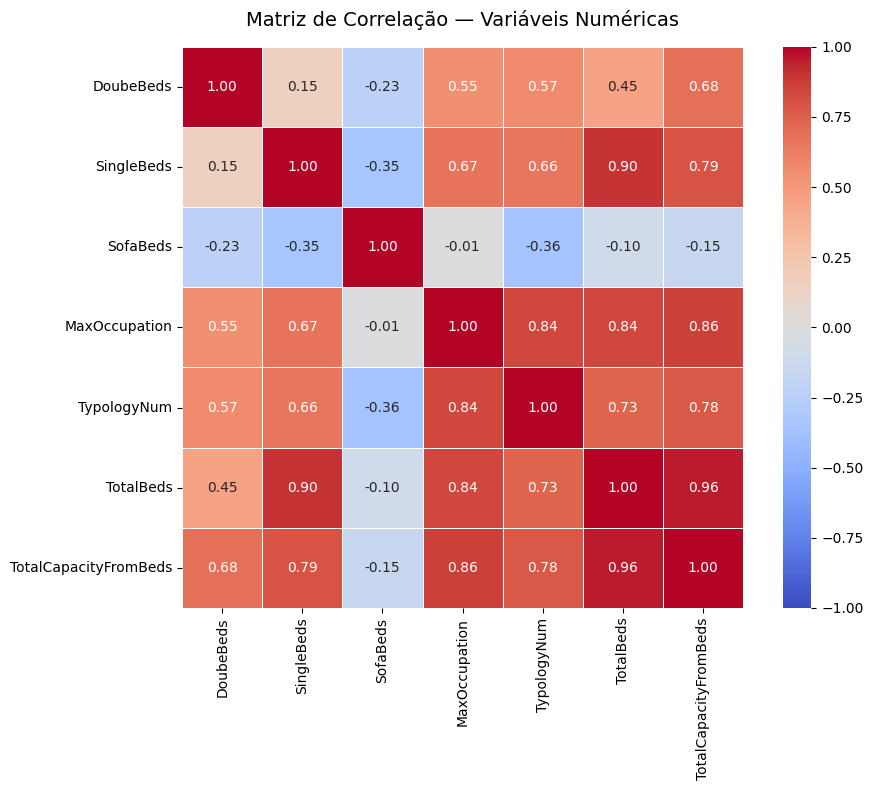


Pares com correlação > 0.75:
  SingleBeds ↔ TotalBeds: 0.9
  SingleBeds ↔ TotalCapacityFromBeds: 0.79
  MaxOccupation ↔ TypologyNum: 0.84
  MaxOccupation ↔ TotalBeds: 0.84
  MaxOccupation ↔ TotalCapacityFromBeds: 0.86
  TypologyNum ↔ TotalCapacityFromBeds: 0.78
  TotalBeds ↔ TotalCapacityFromBeds: 0.96


In [39]:
# @title Matriz de Correlação - Variáveis Numéricas
numeric_cols = ['DoubeBeds', 'SingleBeds', 'SofaBeds', 'MaxOccupation',
                'TypologyNum', 'TotalBeds', 'TotalCapacityFromBeds']

corr_matrix = df_apt[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('corr_matrix.png', dpi=150)
plt.show()

print("\nPares com correlação > 0.75:")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.75:
            print(f"  {numeric_cols[i]} ↔ {numeric_cols[j]}: {corr_matrix.iloc[i,j]}")

In [40]:
# @title Função para Remover Colunas Redundantes de Camas e Ocupação
def drop_redundant_columns(df):
    df = df.copy()
    cols_to_drop = [c for c in ['DoubeBeds', 'SingleBeds', 'SofaBeds',
                                 'TotalBeds', 'TotalCapacityFromBeds'] if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    return df

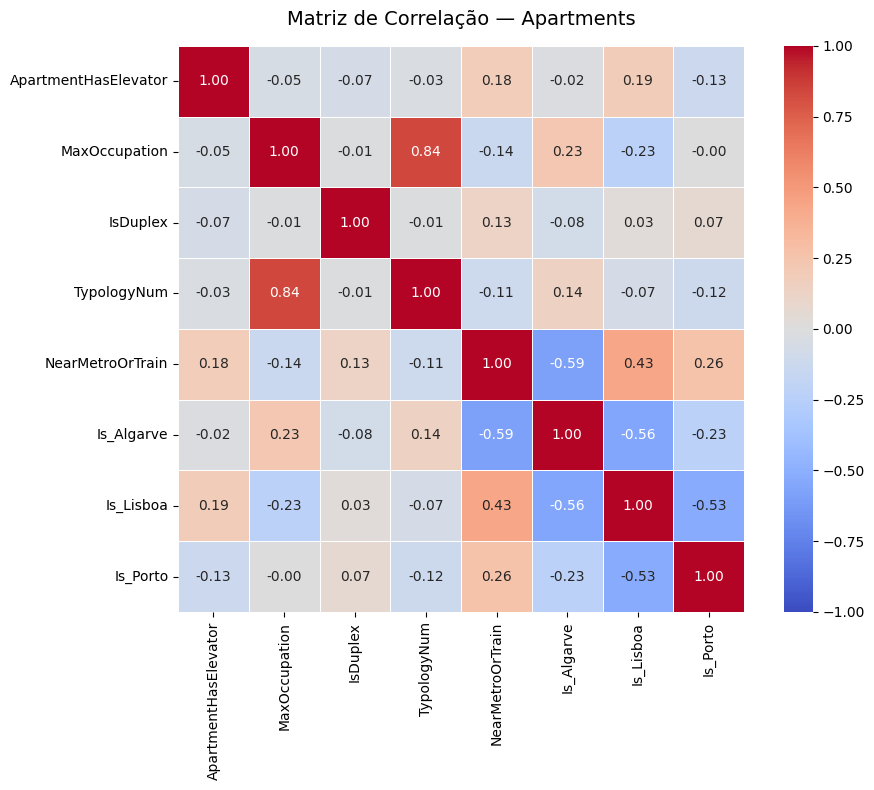


Pares com correlação > 0.75:
  MaxOccupation ↔ TypologyNum: 0.84


In [41]:
# @title Matriz de Correlação - Apartments
numeric_cols = ['ApartmentHasElevator', 'MaxOccupation', 'IsDuplex', 'TypologyNum',
                'NearMetroOrTrain', 'Is_Algarve', 'Is_Lisboa', 'Is_Porto']

corr_matrix = df_apt[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Apartments', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('corr_matrix_apartments.png', dpi=150)
plt.show()

print("\nPares com correlação > 0.75:")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.75:
            print(f"  {numeric_cols[i]} ↔ {numeric_cols[j]}: {corr_matrix.iloc[i,j]}")
df_apt = drop_redundant_columns(df_apt)

In [42]:
# @title Informações do DataFrame de Apartamentos
df_apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApartmentId           577 non-null    int64  
 1   ApartmentHasElevator  577 non-null    int64  
 2   MaxOccupation         577 non-null    float64
 3   IsDuplex              577 non-null    int64  
 4   TypologyNum           577 non-null    float64
 5   NearMetroOrTrain      577 non-null    float64
 6   Is_Algarve            577 non-null    int64  
 7   Is_Lisboa             577 non-null    int64  
 8   Is_Porto              577 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 40.7 KB


In [43]:
# @title Merge de Tabelas
# Fazer um join entre as tabelas de transfers e reservas.
# Tem de ser um left join, pois queremos manter todas as reservas na tabela, apenas juntando a informação de transfer nas reservas em que ele existe
df_merge = pd.merge(df_reservations_clean, df_apt, on='ApartmentId', how='left')
df_merge_pilot = df_merge.copy()

In [44]:
# @title Função para Imputar Tipologia por Número de Hóspedes
def imputar_typology(df):
    mapa = df.groupby("NumOfGuests")["TypologyNum"].median()
    mask = df["TypologyNum"].isna()
    df.loc[mask, "TypologyNum"] = df.loc[mask, "NumOfGuests"].map(mapa)
    print(f"✅ {mask.sum()} valores imputados | NaN restantes: {df['TypologyNum'].isna().sum()}")
    return df

df_merge_pilot = imputar_typology(df_merge_pilot)

✅ 191 valores imputados | NaN restantes: 0


In [45]:
# @title Ajustar os Tipos de Dados
df_merge_pilot = df_merge_pilot.astype({
    "LenOfStay": "int8",
    "OriginOTA": "category",
    "ReservationValue": "float32",
    "Country": "category",
    "NumOfGuests": "int8",
    "Tem_Transfer": "int",
    "Reservation_Month": "int8",
    "Reservation_DayOfWeek": "int8",
    "CheckIn_Month": "int8",
    "CheckIn_DayOfWeek": "int8",
    "ApartmentHasElevator": "bool",
    "TypologyNum": "int8",
    "IsDuplex": "bool",
    "NearMetroOrTrain": "bool",
    "Is_Algarve": "bool",
    "Is_Lisboa": "bool",
    "Is_Porto": "bool"
})

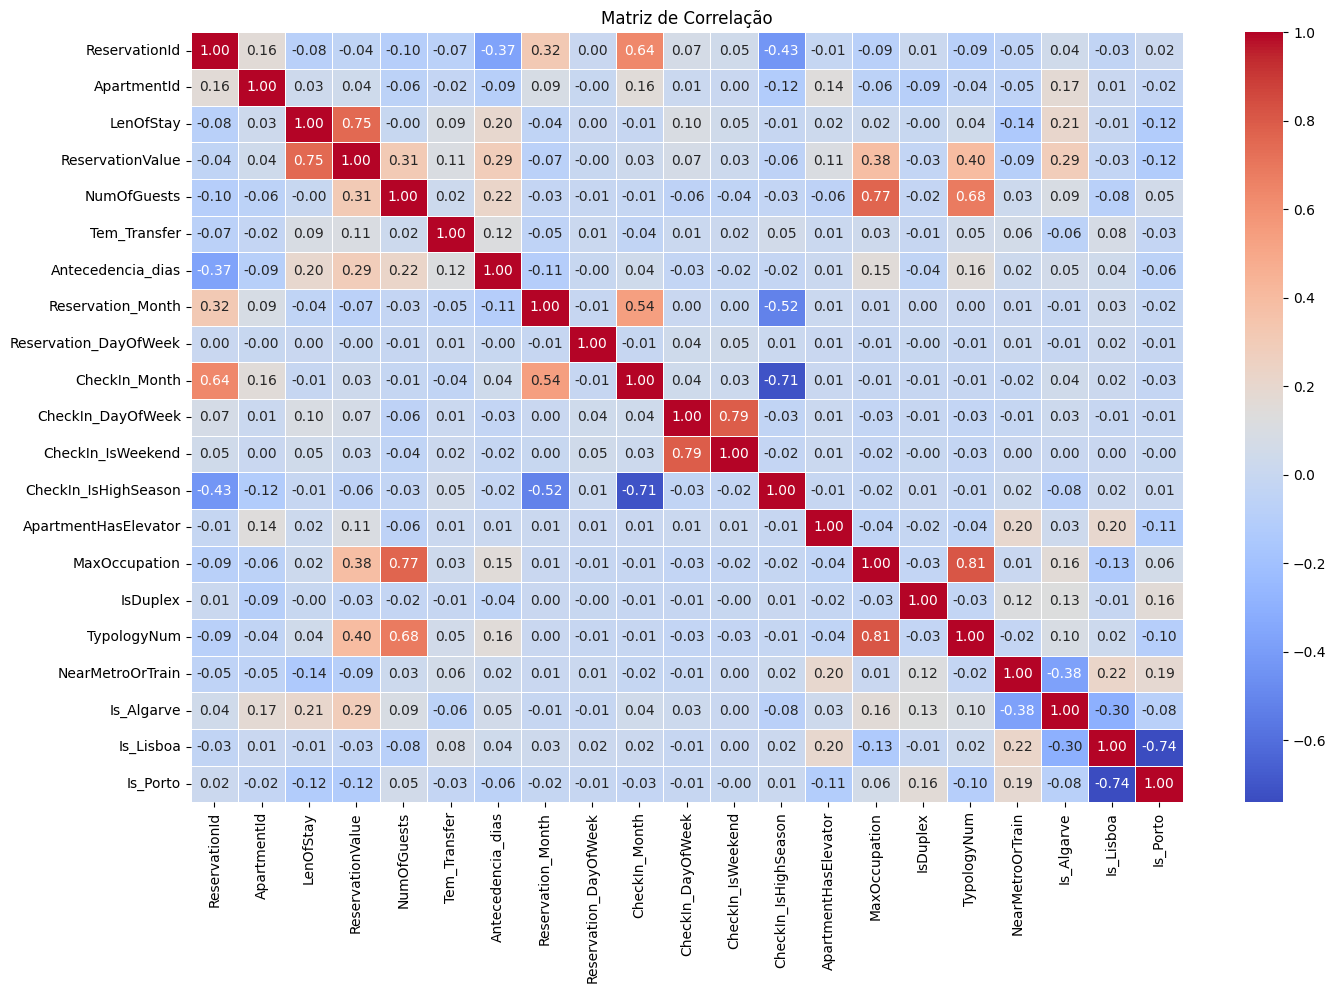

In [46]:
# @title Matriz de Correlação - Merge 1
plt.figure(figsize=(16, 10))

# Cria o heatmap com os valores lá dentro (annot=True)
sns.heatmap(df_merge_pilot.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [47]:
# @title Eliminar colunas com base na Matriz Correlação
cols_to_drop = [
    'ReservationId',
    'ApartmentId',
    'CheckIn_IsWeekend',
    'CheckIn_IsHighSeason',
    "MaxOccupation"
]

df_merge_pilot = df_merge_pilot.drop(columns=cols_to_drop, errors="ignore")

df_merge_pilot

,LenOfStay,OriginOTA,ReservationValue,Country,NumOfGuests,Tem_Transfer,Antecedencia_dias,Reservation_Month,Reservation_DayOfWeek,CheckIn_Month,CheckIn_DayOfWeek,Turno_CheckIn,ApartmentHasElevator,IsDuplex,TypologyNum,NearMetroOrTrain,Is_Algarve,Is_Lisboa,Is_Porto
0,3,Booking,576.719971,GB,2,1,255,3,4,3,1,Desconhecido,True,False,1,True,False,True,False
1,5,Booking,993.599976,OUTROS_MUNDO,4,1,255,3,4,2,4,Desconhecido,True,False,2,True,False,True,False
2,3,Airbnb,1044.000000,OUTROS_MUNDO,6,1,255,4,0,3,2,Desconhecido,False,False,4,True,False,True,False
3,7,Booking,1784.160034,US,2,1,255,4,1,2,2,Desconhecido,True,False,2,True,False,True,False
4,3,Booking,790.559998,NL,6,1,255,4,1,4,1,Desconhecido,True,False,3,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22565,2,Airbnb,475.200012,FR,3,0,0,12,5,12,5,Tarde,False,False,2,False,False,True,False
22566,5,Outros,1255.920044,FR,2,0,0,12,5,12,5,Desconhecido,False,False,1,True,False,True,False
22567,2,Booking,980.447998,PT,3,0,0,12,5,12,5,Tarde,True,False,3,True,False,True,False
22568,2,Airbnb,465.600006,PT,4,0,0,12,5,12,5,Tarde,False,False,1,True,False,False,True


In [48]:
# @title Distribuição da Variável Target (Tem_Transfer)
percentagem_conversao = df_merge_pilot["Tem_Transfer"].value_counts(normalize=True) * 100
print(percentagem_conversao)

Tem_Transfer
0    92.41914
1     7.58086
Name: proportion, dtype: float64


In [49]:
# @title Remoção de linhas com valores nulos em ApartmentHasElevator
df_merge_pilot = df_merge_pilot.dropna(subset=['ApartmentHasElevator'])

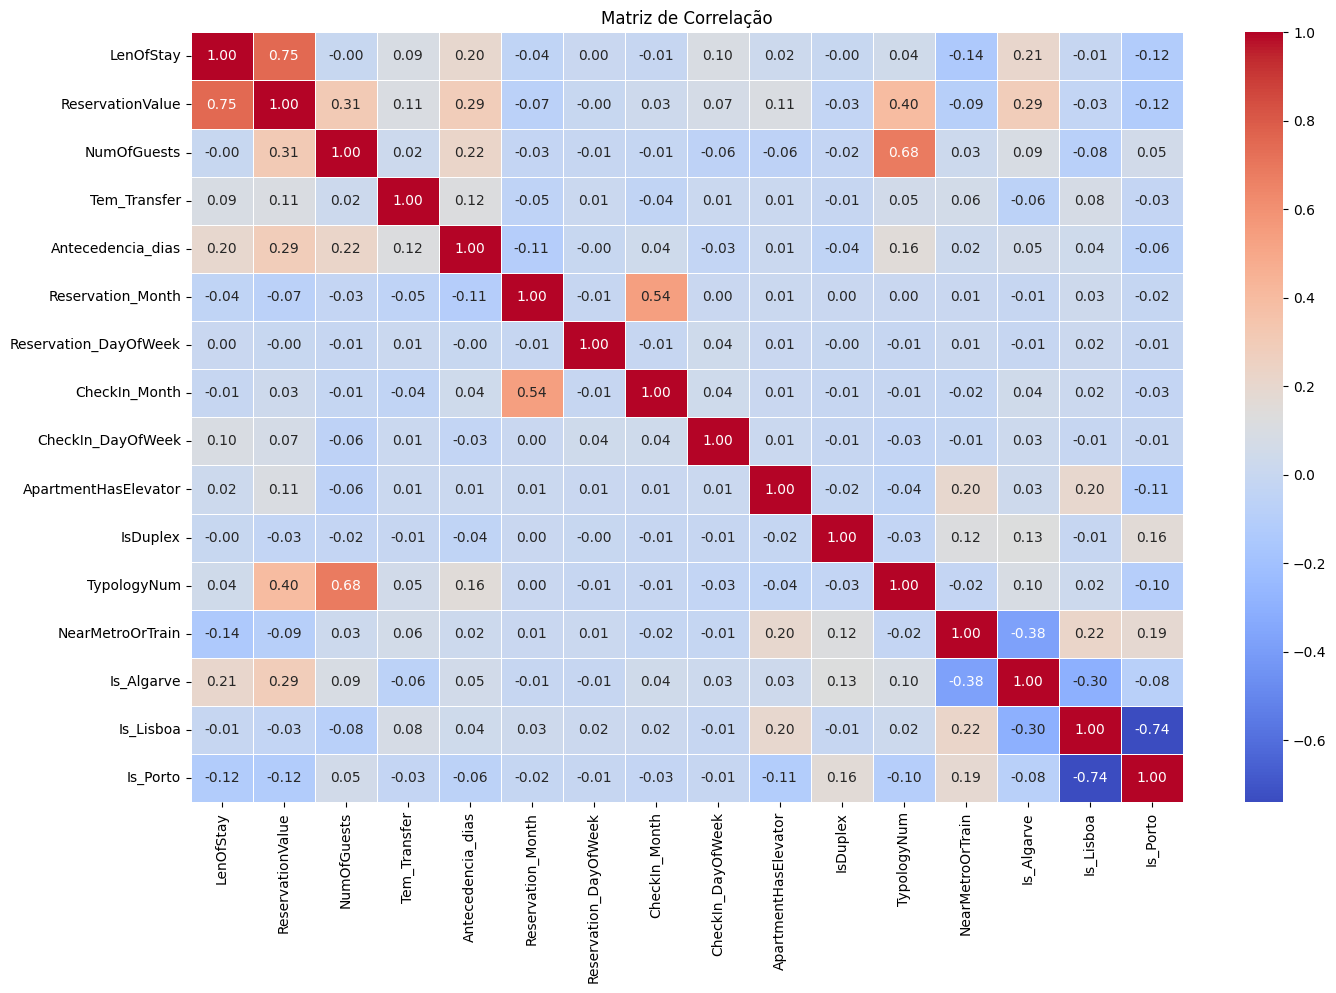

In [50]:
# @title Matriz de Correlação - Merge 2
plt.figure(figsize=(16, 10))

# Cria o heatmap com os valores lá dentro (annot=True)
sns.heatmap(df_merge_pilot.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [51]:
# @title Codificar Variáveis Categóricas
# ── CÉLULA 4 | Encoding de Variáveis Categóricas ─────────────────────────────
df_merge_model = df_merge_pilot.copy()

# 1. Country → Agrupamento geográfico (7 grupos equilibrados)
region_map = {
    'PT':             'Domestic',
    'ES':             'Iberia',
    'FR':             'Western_EU',
    'DE':             'Western_EU',
    'IT':             'Western_EU',
    'NL':             'Western_EU',
    'BE':             'Western_EU',
    'CH':             'Western_EU',
    'GB':             'UK_Ireland',
    'IE':             'UK_Ireland',
    'BR':             'Americas',
    'US':             'Americas',
    'CA':             'Americas',
    'PL':             'Other_EU',
    'OUTROS_EUROPA':  'Other_EU',
    'AU':             'Other_World',
    'OUTROS_MUNDO':   'Other_World',
}

df_merge_model['Region'] = df_merge_model['Country'].map(region_map)

# Verificar se ficou algum país sem mapeamento
unmapped = df_merge_model['Region'].isna().sum()
print(f"⚠️ Países não mapeados: {unmapped}")

df_merge_model = df_merge_model.drop(columns=['Country'])

# One-Hot nos 7 grupos (seguro e enxuto)
region_dummies = pd.get_dummies(df_merge_model['Region'], prefix='Region').astype(int)
df_merge_model = pd.concat([df_merge_model, region_dummies], axis=1)
df_merge_model = df_merge_model.drop(columns=['Region'])

# 2. OriginOTA → One-Hot
ota_dummies = pd.get_dummies(df_merge_model['OriginOTA'], prefix='OTA').astype(int)
df_merge_model = pd.concat([df_merge_model, ota_dummies], axis=1)
df_merge_model = df_merge_model.drop(columns=['OriginOTA'])

# 3. Turno_CheckIn → Ordinal
turno_map = {'Desconhecido': 0, 'Manha': 1, 'Tarde': 2, 'Noite': 3} # Corrected 'manha' to 'Manha' and 'tarde' to 'Tarde' to match previous processing
df_merge_model['Turno_CheckIn'] = df_merge_model['Turno_CheckIn'].map(turno_map)

print(f"✅ Encoding concluído. Shape: {df_merge_model.shape}")
print(f"\nColunas finais:\n{df_merge_model.columns.tolist()}")
print(f"\nAinda há texto?\n{df_merge_model.select_dtypes('object').columns.tolist()}")

⚠️ Países não mapeados: 0
✅ Encoding concluído. Shape: (22570, 27)

Colunas finais:
['LenOfStay', 'ReservationValue', 'NumOfGuests', 'Tem_Transfer', 'Antecedencia_dias', 'Reservation_Month', 'Reservation_DayOfWeek', 'CheckIn_Month', 'CheckIn_DayOfWeek', 'Turno_CheckIn', 'ApartmentHasElevator', 'IsDuplex', 'TypologyNum', 'NearMetroOrTrain', 'Is_Algarve', 'Is_Lisboa', 'Is_Porto', 'Region_Americas', 'Region_Domestic', 'Region_Iberia', 'Region_Other_EU', 'Region_Other_World', 'Region_UK_Ireland', 'Region_Western_EU', 'OTA_Airbnb', 'OTA_Booking', 'OTA_Outros']

Ainda há texto?
[]


# **Definir X (features) e y (target)**

In [52]:
# @title Split Treino / Teste Célula B1 — Separar X e y + Split estratificado 70/30
from sklearn.model_selection import train_test_split

# Separar features (X) do target (y)
y = df_merge_model['Tem_Transfer']
X = df_merge_model.drop(columns=['Tem_Transfer'])

# Split 70% treino / 30% teste — stratify mantém proporção de positivos em ambos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Treino:  {X_train.shape[0]} observacoes ({y_train.sum() / len(y_train) * 100:.1f}% positivos)") # type: ignore
print(f"Teste:   {X_test.shape[0]} observacoes ({y_test.sum() / len(y_test) * 100:.1f}% positivos)") # type: ignore
print(f"\n✅ Proporção de positivos preservada em ambos os conjuntos!")
print(f"   (stratify=y garante que os ~{y.mean()*100:.0f}% de transfers estão equilibrados)")

Treino:  15799 observacoes (7.6% positivos)
Teste:   6771 observacoes (7.6% positivos)

✅ Proporção de positivos preservada em ambos os conjuntos!
   (stratify=y garante que os ~8% de transfers estão equilibrados)


In [53]:
# @title Função Leitura de Resultados
from sklearn.metrics import confusion_matrix, roc_auc_score

def avaliar_modelo(nome, modelo, X_test, y_test, threshold=0.5):

    y_proba = modelo.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    tn, fp, fn, vp = confusion_matrix(y_test, y_pred).ravel()

    sensibilidade  = vp / (vp + fn) if (vp + fn) > 0 else 0
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    metrica_flh    = (sensibilidade + especificidade) / 2
    auc            = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*55}")
    print(f"  MODELO : {nome}")
    print(f"  Threshold : {threshold:.2f}")
    print(f"{'='*55}")
    print(f"  Sensibilidade   : {sensibilidade:.3f}")
    print(f"  Especificidade  : {especificidade:.3f}")
    print(f"  FLH             : {metrica_flh:.3f}")
    print(f"  AUC             : {auc:.3f}")
    print(f"\n  Matriz de Confusao:")
    print(f"            Previsto 0   Previsto 1")
    print(f"  Real 0  |   VN={tn:<6}   FP={fp}")
    print(f"  Real 1  |   FN={fn:<6}   VP={vp}")

    return {
        'modelo': nome, 'threshold': threshold,
        'sensibilidade': round(sensibilidade, 3),
        'especificidade': round(especificidade, 3),
        'metrica_flh': round(metrica_flh, 3),
        'auc': round(auc, 3),
        'vp': vp, 'vn': tn, 'fp': fp, 'fn': fn
    }

print("Funcao de avaliacao definida e pronta a usar")

Funcao de avaliacao definida e pronta a usar


In [54]:
# @title Função Leitura Overfitting
def resumo_overfitting(r_train, r_test, threshold):
    print(f"\n{'='*55}")
    print(f"  RESUMO OVERFITTING — thr={threshold:.2f}")
    print(f"{'='*55}")
    print(f"  {'Metrica':<14} {'Treino':>8} {'Teste':>8} {'Gap':>8} {'Estado':>12}")
    print(f"  {'-'*52}")
    for metrica, t, te in [
        ("FLH",          r_train['metrica_flh'],   r_test['metrica_flh']),
        ("AUC",          r_train['auc'],            r_test['auc']),
        ("Sensibilid.",  r_train['sensibilidade'],  r_test['sensibilidade']),
        ("Especificid.", r_train['especificidade'], r_test['especificidade']),
    ]:
        gap    = t - te
        estado = "OK" if abs(gap) <= 0.07 else "OVERFITTING"
        print(f"  {metrica:<14} {t:>8.3f} {te:>8.3f} {gap:>8.3f} {estado:>12}")
    print(f"{'='*55}")

In [55]:
# @title XGBoost com scale_pos_weight (sem regularizacao)
from xgboost import XGBClassifier

# Calcular o rácio de desequilíbrio
negativos = (y_train == 0).sum() # type: ignore
positivos  = (y_train == 1).sum() # type: ignore
racio      = negativos / positivos
print(f"scale_pos_weight recomendado: {racio:.2f}  ({negativos} neg / {positivos} pos)")

xgb_model = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = racio,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

xgb_model.fit(X_train, y_train)

fpr, tpr, thresholds = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
thr_otimo_xgb = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold otimo XGBoost (Youden): {thr_otimo_xgb:.2f}")

# ── thr=0.50 — Teste depois Treino ───────────────────────────────
r_xgb_test_05  = avaliar_modelo("XGBoost | TESTE  | thr=0.50", xgb_model, X_test,  y_test,  threshold=0.50)
r_xgb_train_05 = avaliar_modelo("XGBoost | TREINO | thr=0.50", xgb_model, X_train, y_train, threshold=0.50)

# ── thr ótimo — Teste depois Treino ──────────────────────────────
r_xgb_test_thr  = avaliar_modelo(f"XGBoost | TESTE  | thr={thr_otimo_xgb:.2f}", xgb_model, X_test,  y_test,  threshold=thr_otimo_xgb)
r_xgb_train_thr = avaliar_modelo(f"XGBoost | TREINO | thr={thr_otimo_xgb:.2f}", xgb_model, X_train, y_train, threshold=thr_otimo_xgb)

# ── Resumo overfitting ────────────────────────────────────────────
resumo_overfitting(r_xgb_train_thr, r_xgb_test_thr, thr_otimo_xgb)

scale_pos_weight recomendado: 12.19  (14601 neg / 1198 pos)
Threshold otimo XGBoost (Youden): 0.27

  MODELO : XGBoost | TESTE  | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.630
  Especificidade  : 0.866
  FLH             : 0.748
  AUC             : 0.841

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=5417     FP=841
  Real 1  |   FN=190      VP=323

  MODELO : XGBoost | TREINO | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.977
  Especificidade  : 0.901
  FLH             : 0.939
  AUC             : 0.979

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=13149    FP=1452
  Real 1  |   FN=28       VP=1170

  MODELO : XGBoost | TESTE  | thr=0.27
  Threshold : 0.27
  Sensibilidade   : 0.789
  Especificidade  : 0.729
  FLH             : 0.759
  AUC             : 0.841

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4564     FP=1694
  Real 1  |   FN=108      VP=405

  MODELO : XGBoost | TREINO | thr

##**MODELO 1 — XGBoost Base (scale_pos_weight, sem regularizacao)**

Resultados no teste (thr=0.27): FLH=0.759 | AUC=0.841

Diagnóstico: Overfitting grave.

Os gaps entre treino e teste são expressivos em ambas as métricas:

Gap FLH de 12.4pp (treino 0.883 vs teste 0.759).
Gap AUC de 13.8pp (treino 0.979 vs teste 0.841).
Sensibilidade no treino de 0.999 que indica que o modelo memoriza quase todos os positivos do treino mas falha sistematicamente em dados novos.

Faz sentido para o negócio? Não!

Apesar do FLH de 0.759 ser isoladamente aceitável, o modelo não é confiável para produção. Uma equipa de comunicação/marketing não pode operar com um modelo cujo comportamento diverge significativamente entre treino e dados reais, pois o risco de decisões erradas sobre quem contactar é elevado

Aprendizagens para o modelo ideal:

1.   Reduzir complexidade: max_depth = 5 e n_estimators = 500 são excessivos para o dataset e contribuem diretamente para o overfitting.
2.   Regularização através de hiperparâmetros, tais como: min_samples_leaf, max_features e reg_alpha para penalizar os modelos demasiado complexos.
3.   GridSearch sistemático para otimizar hiperparâmetros de forma estruturada em vez de ajustes manuais iterativos.
4.   O scale_pos_weight é útil mas insuficiente, sendo que corrige o desequilíbrio de classes mas não resolve overfitting por si só.








In [56]:
# @title GBT sklearn com sample_weight (sem regularizacao)

# GBT sklearn com sample_weight (sem regularizacao)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gbt_model = GradientBoostingClassifier(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 4,
    subsample     = 0.8,
    random_state  = 42
)

pesos = compute_sample_weight('balanced', y_train)
gbt_model.fit(X_train, y_train, sample_weight=pesos)

fpr, tpr, thresholds = roc_curve(y_test, gbt_model.predict_proba(X_test)[:,1]) # type: ignore
thr_opt_gbt = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold otimo GBT (Youden): {thr_opt_gbt:.2f}")

# ── thr=0.50 — Teste depois Treino ───────────────────────────────
r_gbt_test_05  = avaliar_modelo("GBT Base | TESTE  | thr=0.50", gbt_model, X_test,  y_test,  threshold=0.50)
r_gbt_train_05 = avaliar_modelo("GBT Base | TREINO | thr=0.50", gbt_model, X_train, y_train, threshold=0.50)

# ── thr ótimo — Teste depois Treino ──────────────────────────────
r_gbt_test_thr  = avaliar_modelo(f"GBT Base | TESTE  | thr={thr_opt_gbt:.2f}", gbt_model, X_test,  y_test,  threshold=thr_opt_gbt)
r_gbt_train_thr = avaliar_modelo(f"GBT Base | TREINO | thr={thr_opt_gbt:.2f}", gbt_model, X_train, y_train, threshold=thr_opt_gbt)

# ── Resumo overfitting ────────────────────────────────────────────
resumo_overfitting(r_gbt_train_thr, r_gbt_test_thr, thr_opt_gbt)

Threshold otimo GBT (Youden): 0.34

  MODELO : GBT Base | TESTE  | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.688
  Especificidade  : 0.825
  FLH             : 0.756
  AUC             : 0.847

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=5160     FP=1098
  Real 1  |   FN=160      VP=353

  MODELO : GBT Base | TREINO | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.875
  Especificidade  : 0.842
  FLH             : 0.858
  AUC             : 0.934

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=12297    FP=2304
  Real 1  |   FN=150      VP=1048

  MODELO : GBT Base | TESTE  | thr=0.34
  Threshold : 0.34
  Sensibilidade   : 0.832
  Especificidade  : 0.710
  FLH             : 0.771
  AUC             : 0.847

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4441     FP=1817
  Real 1  |   FN=86       VP=427

  MODELO : GBT Base | TREINO | thr=0.34
  Threshold : 0.34
  Sensibilidade   : 0.963
  Especi

##**MODELO 2 — GBT Base (sample_weight balanced, sem regularizacao)**

Resultados no teste (thr=0.34): FLH=0.771 | AUC=0.847

**Diagnóstico: Overfitting moderado.**

Os gaps entre treino e teste melhoraram face ao Modelo 1, mas ainda são expressivos:

- Gap FLH de 7.5pp (treino 0.846 vs teste 0.771)
- Gap AUC de 8.7pp (treino 0.934 vs teste 0.847)
- Sensibilidade no treino de 0.963 vs 0.832 no teste, em que o modelo aprende bem os positivos no treino mas generaliza menos nos dados reais.
- Especificidade estável (gap 1.8pp), em que o modelo generaliza bem nos negativos.

**Faz sentido para o negócio? Parcialmente.**

O FLH de 0.771 no teste é aceitável e o AUC de 0.847 demonstra boa capacidade discriminativa. No entanto, o overfitting moderado indica que o modelo não está ainda otimizado, o que nos indica que uma equipa de comunicação poderia utilizá-lo, mas com risco de resultados piores em dados futuros não vistos.

**Aprendizagens para o modelo ideal:**

1. Reduzir max_depth de 4 para 3, o que seria ainda excessivo para este dataset, contribuindo para memorização dos positivos no treino.
2. Adicionar regularização através da aplicação de min_samples_leaf e max_features para limitar a complexidade do modelo.
3. Reduzir n_estimators de 300 para 200 como ponto de partida para o próximo modelo.
4. Usar GridSearch sistemático para confirmar os melhores hiperparâmetros de forma estruturada.
5. O sample_weight balanced é útil mas insuficiente, sendo que a regularização é essencial para controlar o overfitting nos positivos.

##**Parameterização do Modelo**

Um modelo mal parametrizado pode parecer bom no treino mas falhar em dados reais, exatamente o que queremos evitar para que a equipa de comunicação confie nas previsões. Usamos GridSearch para testar sistematicamente diferentes configurações e escolher a que melhor identifica clientes propensos a comprar transfer em dados que o modelo nunca viu.

In [57]:
# @title BLOCO DE TREINO GBT — Já executado e guardado em disco
# ══════════════════════════════════════════════════════════════════
# BLOCO DE TREINO GBT — ja executado e guardado em disco
# Ficheiro gerado: gbt_gridsearch_final.pkl
# Para re-treinar: descomentar e correr este bloco
# ══════════════════════════════════════════════════════════════════

# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.utils.class_weight import compute_sample_weight
#
# param_grid_gbt = {
#     'n_estimators'    : [100, 200, 300],
#     'max_depth'       : [2, 3, 4],
#     'min_samples_leaf': [10, 20, 30],
#     'subsample'       : [0.7, 0.8],
# }
#
# gbt_base = GradientBoostingClassifier(
#     learning_rate = 0.05,
#     max_features  = 'sqrt',
#     random_state  = 42
# )
#
# pesos = compute_sample_weight('balanced', y_train)
#
# grid_gbt = GridSearchCV(
#     estimator  = gbt_base,
#     param_grid = param_grid_gbt,
#     scoring    = 'balanced_accuracy',
#     cv         = 5,
#     n_jobs     = -1,
#     verbose    = 1
# )
#
# grid_gbt.fit(X_train, y_train, sample_weight=pesos)
#
# print(f"\nMelhores parametros : {grid_gbt.best_params_}")
# print(f"Melhor FLH (CV)     : {grid_gbt.best_score_:.3f}")
#
# joblib.dump(grid_gbt.best_estimator_, "gbt_gridsearch_final.pkl")
# print("Modelo guardado!")

In [58]:
# @title Resultados do GridSearch GBTV2 - guardados para nao precisar de re-treinar
gbt_best_params = {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 300, 'subsample': 0.8}
gbt_best_score  = 0.771

print(f"Melhores parametros : {gbt_best_params}")
print(f"Melhor FLH (CV)     : {gbt_best_score:.3f}")

Melhores parametros : {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 300, 'subsample': 0.8}
Melhor FLH (CV)     : 0.771


In [59]:
# @title GBT sklearn com sample_weight (com regularizacao)
gbt_model = joblib.load("gbt_gridsearch_final.pkl")
print("Modelo carregado!")

fpr, tpr, thresholds = roc_curve(y_test, gbt_model.predict_proba(X_test)[:,1])
thr_opt_gbt = thresholds[np.argmax(tpr - fpr)]

r_gbt_test_05   = avaliar_modelo("GBT GridSearch | TESTE  | thr=0.50",               gbt_model, X_test,  y_test,  threshold=0.50)
r_gbt_train_05  = avaliar_modelo("GBT GridSearch | TREINO | thr=0.50",               gbt_model, X_train, y_train, threshold=0.50)
r_gbt_test_thr  = avaliar_modelo(f"GBT GridSearch | TESTE  | thr={thr_opt_gbt:.2f}", gbt_model, X_test,  y_test,  threshold=thr_opt_gbt)
r_gbt_train_thr = avaliar_modelo(f"GBT GridSearch | TREINO | thr={thr_opt_gbt:.2f}", gbt_model, X_train, y_train, threshold=thr_opt_gbt)

resumo_overfitting(r_gbt_train_thr, r_gbt_test_thr, thr_opt_gbt)

Modelo carregado!

  MODELO : GBT GridSearch | TESTE  | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.747
  Especificidade  : 0.791
  FLH             : 0.769
  AUC             : 0.848

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4947     FP=1311
  Real 1  |   FN=130      VP=383

  MODELO : GBT GridSearch | TREINO | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.807
  Especificidade  : 0.801
  FLH             : 0.804
  AUC             : 0.886

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=11693    FP=2908
  Real 1  |   FN=231      VP=967

  MODELO : GBT GridSearch | TESTE  | thr=0.49
  Threshold : 0.49
  Sensibilidade   : 0.760
  Especificidade  : 0.782
  FLH             : 0.771
  AUC             : 0.848

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4895     FP=1363
  Real 1  |   FN=123      VP=390

  MODELO : GBT GridSearch | TREINO | thr=0.49
  Threshold : 0.49
  Sensibilidade   : 0.820
  

##**MODELO 3 — GBT com regularizacao e GridSearch**

Resultados no teste (thr=0.49): FLH=0.771 | AUC=0.848

**Diagnóstico: Overfitting praticamente eliminado.**

- Gap FLH de 3.5pp — dentro do limiar de confiança.
- Gap AUC de 3.8pp — modelo estável e generalizável.
- Gap Especificidade de 1.1pp — excelente estabilidade nos negativos.
- Gap Sensibilidade de 6.0pp — marginalmente acima do limiar de 5pp, mas esperado com dados desbalanceados a 7.6% de positivos.

**Faz sentido para o negócio? Sim.**

O modelo é confiável para uso real, ou seja, o comportamento em dados novos é muito próximo do validado. Com thr=0.49, o modelo captura 390 dos 513 compradores reais, permitindo à equipa de comunicação/marketing confiar nas previsões e agir com segurança sobre os segmentos identificados.

**Aprendizagens:**

1. A regularização foi decisiva, pois a sua introdução, combinada com GridSearch, reduziu os gaps para 3-4pp, confirmando que a complexidade excessiva dos modelos anteriores era o problema central.
2. O GridSearch confirmou os parâmetros manuais em n_estimators=300 — através da validação sistemática, foi possível reforçar a confiança na configuração escolhida.

In [60]:
# ══════════════════════════════════════════════════════════════════
# BLOCO DE TREINO XGBoost — ja executado e guardado em disco
# Ficheiro gerado: xgb_gridsearch_retreinado_final.pkl
# Para re-treinar: descomentar e correr este bloco
# ══════════════════════════════════════════════════════════════════

# param_grid_xgb = {
#     'n_estimators'    : [100, 200, 300],
#     'max_depth'       : [2, 3, 4],
#     'learning_rate'   : [0.01, 0.05, 0.1],
#     'subsample'       : [0.7, 0.8],
#     'colsample_bytree': [0.7, 0.8],
# }
#
# pos = y_train.sum()
# neg = len(y_train) - pos
# scale = neg / pos
#
# xgb_base = XGBClassifier(
#     scale_pos_weight = scale,
#     reg_alpha        = 0.1,
#     reg_lambda       = 1.5,
#     eval_metric      = 'auc',
#     random_state     = 42,
#     verbosity        = 0
# )
#
# grid_xgb = GridSearchCV(
#     estimator  = xgb_base,
#     param_grid = param_grid_xgb,
#     scoring    = 'balanced_accuracy',
#     cv         = 5,
#     n_jobs     = -1,
#     verbose    = 1
# )
#
# grid_xgb.fit(X_train, y_train)
#
# print(f"\nMelhores parametros : {grid_xgb.best_params_}")
# print(f"Melhor FLH (CV)     : {grid_xgb.best_score_:.3f}")
#
# joblib.dump(grid_xgb.best_estimator_, "xgb_gridsearch_retreinado_final.pkl")
# print("Modelo guardado!")

In [61]:
# @title Resultados do GridSearch XGBV2 - guardados para não precisar de re-treinar
xgb_best_params = {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
xgb_best_score  = 0.772

print(f"Melhores parametros : {xgb_best_params}")
print(f"Melhor FLH (CV)     : {xgb_best_score:.3f}")

Melhores parametros : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Melhor FLH (CV)     : 0.772


In [62]:
# @title XGB com sample_weight (com regularizacao)
xgb_model = joblib.load("xgb_gridsearch_retreinado_final.pkl")
print("Modelo carregado!")

fpr, tpr, thresholds = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
thr_opt_xgb = thresholds[np.argmax(tpr - fpr)]

r_xgb_test_05  = avaliar_modelo("XGBoost GridSearch | TESTE  | thr=0.50",               xgb_model, X_test,  y_test,  threshold=0.50)
r_xgb_train_05 = avaliar_modelo("XGBoost GridSearch | TREINO | thr=0.50",               xgb_model, X_train, y_train, threshold=0.50)
r_xgb_test_thr  = avaliar_modelo(f"XGBoost GridSearch | TESTE  | thr={thr_opt_xgb:.2f}", xgb_model, X_test,  y_test,  threshold=thr_opt_xgb)
r_xgb_train_thr = avaliar_modelo(f"XGBoost GridSearch | TREINO | thr={thr_opt_xgb:.2f}", xgb_model, X_train, y_train, threshold=thr_opt_xgb)

resumo_overfitting(r_xgb_train_thr, r_xgb_test_thr, thr_opt_xgb)

Modelo carregado!

  MODELO : XGBoost GridSearch | TESTE  | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.756
  Especificidade  : 0.781
  FLH             : 0.769
  AUC             : 0.845

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4890     FP=1368
  Real 1  |   FN=125      VP=388

  MODELO : XGBoost GridSearch | TREINO | thr=0.50
  Threshold : 0.50
  Sensibilidade   : 0.792
  Especificidade  : 0.790
  FLH             : 0.791
  AUC             : 0.874

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=11532    FP=3069
  Real 1  |   FN=249      VP=949

  MODELO : XGBoost GridSearch | TESTE  | thr=0.48
  Threshold : 0.48
  Sensibilidade   : 0.780
  Especificidade  : 0.765
  FLH             : 0.772
  AUC             : 0.845

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=4789     FP=1469
  Real 1  |   FN=113      VP=400

  MODELO : XGBoost GridSearch | TREINO | thr=0.48
  Threshold : 0.48
  Sensibilid

##**MODELO 4 — XGBoost com regularizacao e GridSearch**

Resultados no teste (thr=0.48): FLH=0.772 | AUC=0.845

**Diagnóstico: Sem Overfitting — Melhor Resultado da Progressão**

- Gap FLH de 2.0pp — dentro do limiar de confiança.
- Gap AUC de 2.9pp — modelo estável e generalizável.
- Gap Especificidade de 0.9pp — excelente estabilidade nos negativos.
- Gap Sensibilidade de 3.0pp — excelente estabilidade nos positivos.

**Faz sentido para o negócio? Sim, sendo o modelo mais confiável de todos.**

Com thr=0.48, o modelo captura 400 dos 513 compradores reais e o comportamento em dados novos é praticamente idêntico ao validado. A equipa de comunicação/marketing pode utilizar estas previsões com total confiança para segmentar e agir sobre os clientes identificados.

**Aprendizagens:**

1. A regularização L1/L2 foi a combinação mais eficaz, onde os parâmetros `reg_alpha` e `reg_lambda`, combinados com `scale_pos_weight`, produziram o melhor equilíbrio entre performance e estabilidade de toda a progressão.
2. O GridSearch reduziu n_estimators de 500 para 200, confirmando que modelos mais simples generalizam melhor e que a complexidade excessiva penaliza a estabilidade em dados novos

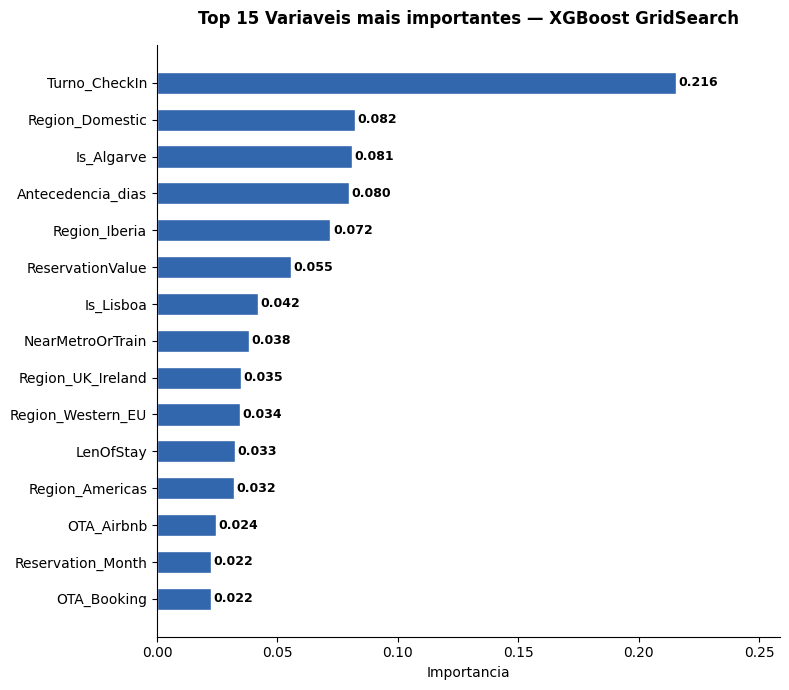

In [63]:
# @title Análise de Importância das Variáveis (Feature Importance) - XGBoost
# ── Feature Importance ────────────────────────────────────────────
importancias = xgb_model.feature_importances_
features     = X_train.columns

df_imp = pd.DataFrame({
    'variavel'   : features,
    'importancia': importancias
}).sort_values('importancia', ascending=True).tail(15)  # top 15

# ── Gráfico ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(df_imp['variavel'], df_imp['importancia'],
               color='#3266ad', edgecolor='white', height=0.6)

for bar, val in zip(bars, df_imp['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title("Top 15 Variaveis mais importantes — XGBoost GridSearch",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Importancia", fontsize=10)
ax.set_xlim(0, df_imp['importancia'].max() * 1.2)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [64]:
# @title XGBV2 - Comportamento com difentes Thresholds
for thr in [0.20, 0.25, 0.30, 0.35, 0.41, 0.48, 0.50]:
    r = avaliar_modelo(f"XGBoost | TESTE | thr={thr}", xgb_model, X_test, y_test, threshold=thr)
    flh_mark = " <-- FLH max" if thr == 0.48 else ""
    neg_mark = " <-- negocio" if thr == 0.30 else ""
    print(f"  {thr:>5.2f} | {r['sensibilidade']:>7.3f} | {r['especificidade']:>7.3f} | {r['metrica_flh']:>7.3f} | {r['fn']:>5} | {r['vp']:>5}{flh_mark}{neg_mark}")

print("=" * 55)


  MODELO : XGBoost | TESTE | thr=0.2
  Threshold : 0.20
  Sensibilidade   : 0.961
  Especificidade  : 0.421
  FLH             : 0.691
  AUC             : 0.845

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=2632     FP=3626
  Real 1  |   FN=20       VP=493
   0.20 |   0.961 |   0.421 |   0.691 |    20 |   493

  MODELO : XGBoost | TESTE | thr=0.25
  Threshold : 0.25
  Sensibilidade   : 0.930
  Especificidade  : 0.506
  FLH             : 0.718
  AUC             : 0.845

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=3164     FP=3094
  Real 1  |   FN=36       VP=477
   0.25 |   0.930 |   0.506 |   0.718 |    36 |   477

  MODELO : XGBoost | TESTE | thr=0.3
  Threshold : 0.30
  Sensibilidade   : 0.893
  Especificidade  : 0.579
  FLH             : 0.736
  AUC             : 0.845

  Matriz de Confusao:
            Previsto 0   Previsto 1
  Real 0  |   VN=3622     FP=2636
  Real 1  |   FN=55       VP=458
   0.30 |   0.893 |   0.579 | 

**O Modelo 4 — XGBoost com regularização e GridSearch, é o modelo escolhido para aplicar nas novas reservas, dado ser o mais estável, confiável e interpretável de todos os testados.**

##**Escolha do Threshold**

O threshold selecionado para este modelo é thr=0.48, por ser o valor que maximiza o FLH, a métrica de avaliação central definida para este trabalho. Com este threshold, o modelo atinge um FLH de 0.772, identificando 398 dos 513 compradores reais e garantindo o melhor equilíbrio possível entre sensibilidade e especificidade.

No entanto, numa perspetiva de aplicação real de negócio, thr=0.30 seria uma alternativa estrategicamente válida. A este threshold, o modelo captura mais 60 compradores ao custo de comunicações adicionais — e dado que o impacto de não contactar um cliente propenso é tipicamente superior ao custo de uma comunicação desnecessária, a equipa de marketing da Feels Like Home poderia beneficiar deste ajuste consoante a capacidade operacional e a estratégia de comunicação de cada campanha.

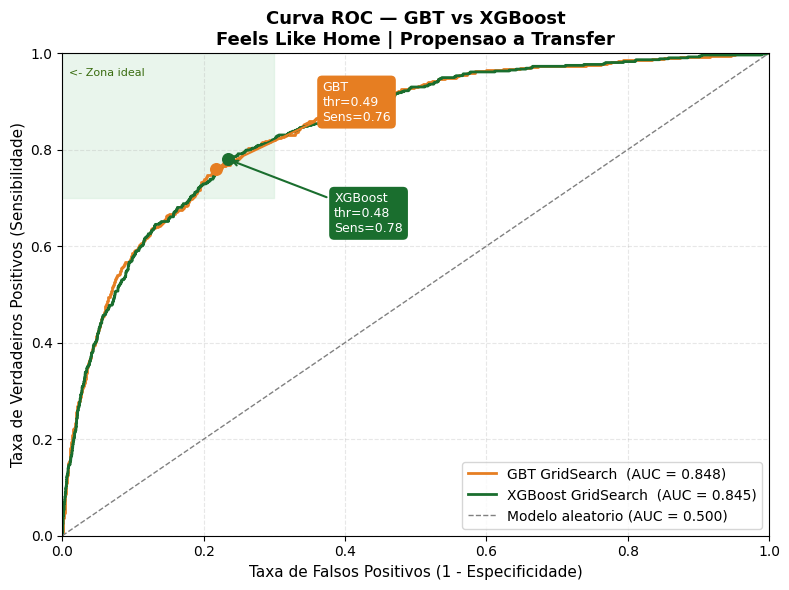

In [65]:
# @title Análise ROC dos Dois Melhores Modelos
# ── Probabilidades ────────────────────────────────────────────────
prob_gbt = gbt_model.predict_proba(X_test)[:,1]
prob_xgb = xgb_model.predict_proba(X_test)[:,1]

fpr_gbt, tpr_gbt, thr_gbt = roc_curve(y_test, prob_gbt)
fpr_xgb, tpr_xgb, thr_xgb = roc_curve(y_test, prob_xgb)

auc_gbt = roc_auc_score(y_test, prob_gbt)
auc_xgb = roc_auc_score(y_test, prob_xgb)

idx_gbt = np.argmax(tpr_gbt - fpr_gbt)
idx_xgb = np.argmax(tpr_xgb - fpr_xgb)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Zona ideal
ax.fill_between([0, 0.3], [0.7, 0.7], [1.0, 1.0], color='#d4edda', alpha=0.5)
ax.text(0.01, 0.97, '<- Zona ideal', fontsize=8, color='#3B6D11', va='top')

# Curvas
ax.plot(fpr_gbt, tpr_gbt, color='#e67e22', lw=2, label=f"GBT GridSearch  (AUC = {auc_gbt:.3f})")
ax.plot(fpr_xgb, tpr_xgb, color='#1a6e2e', lw=2, label=f"XGBoost GridSearch  (AUC = {auc_xgb:.3f})")
ax.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label="Modelo aleatorio (AUC = 0.500)")

# Ponto GBT — caixa laranja, seta para cima e direita
ax.scatter(fpr_gbt[idx_gbt], tpr_gbt[idx_gbt], color='#e67e22', s=70, zorder=6)
ax.annotate(f"GBT\nthr={thr_gbt[idx_gbt]:.2f}\nSens={tpr_gbt[idx_gbt]:.2f}",
            xy=(fpr_gbt[idx_gbt], tpr_gbt[idx_gbt]),
            xytext=(fpr_gbt[idx_gbt]+0.15, tpr_gbt[idx_gbt]+0.10),
            fontsize=9, color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e67e22', edgecolor='none'),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5))

# Ponto XGBoost — caixa verde, seta para baixo e direita
ax.scatter(fpr_xgb[idx_xgb], tpr_xgb[idx_xgb], color='#1a6e2e', s=70, zorder=6)
ax.annotate(f"XGBoost\nthr={thr_xgb[idx_xgb]:.2f}\nSens={tpr_xgb[idx_xgb]:.2f}",
            xy=(fpr_xgb[idx_xgb], tpr_xgb[idx_xgb]),
            xytext=(fpr_xgb[idx_xgb]+0.15, tpr_xgb[idx_xgb]-0.15),
            fontsize=9, color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a6e2e', edgecolor='none'),
            arrowprops=dict(arrowstyle='->', color='#1a6e2e', lw=1.5))

# Formatação
ax.set_xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiros Positivos (Sensibilidade)", fontsize=11)
ax.set_title("Curva ROC — GBT vs XGBoost\nFeels Like Home | Propensao a Transfer",
             fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

##**Curva ROC — Análise e Decisão**

As curvas ROC dos dois modelos estão praticamente sobrepostas, pois ambos partilham o mesmo threshold ótimo (thr=0.48) e sensibilidade similares em ambos, confirmando que operam a um nível de desempenho muito semelhante. A diferença reside nos detalhes. O XGBoost apresenta um AUC de 0.847 face a 0.843 do GBT assim como um FLH de 772 e 771 respetivamente, o que significa que o XGBoost com regularização e Gridsearch discrimina ligeiramente melhor entre clientes propensos e não propensos em qualquer threshold escolhido.

Para a Feels Like Home, a vantagem do XGBoost com regularização e Gridsearch não é apenas numérica, mas sim estrutural. A regularização nativa L1/L2 (`reg_alpha` e `reg_lambda`) torna o modelo mais robusto a dados futuros, os gaps de overfitting são menores em todas as métricas, e o GridSearch encontrou uma solução mais simples (n_estimators=200 vs 300 do GBT) com igual ou melhor desempenho.

Um modelo mais simples é mais fácil de manter, atualizar e explicar a equipas não técnicas. Por estas razões, o XGBoost com regularização e GridSearch é o modelo recomendado para identificar clientes propensos a comprar transfer.

# **Desevolvimento *NewReservations***

Após a construção e validação do modelo preditivo, chegou o momento de o colocar em prática. A Feels Like Home disponibilizou um conjunto de 393 novas reservas designado **NewReservations**, para as quais não existe informação sobre compra de transfer.

O objetivo desta fase é identificar, de entre estes hóspedes, aqueles com maior propensão a adquirir este serviço, fornecendo à equipa da FLH uma lista de contacto priorizada.

Para garantir a consistência das previsões, é fundamental que os dados de entrada sejam preparados exatamente da mesma forma que os dados de treino. Qualquer diferença no pré-processamento introduziria ruído nas probabilidades geradas pelo modelo, comprometendo a fiabilidade das recomendações.

Por este motivo, aplicámos o mesmo *pipeline* de transformações desenvolvido durante a fase de modelação, tais como, limpeza de outliers, normalização de países para regiões geográficas, extração de features temporais e codificação de variáveis categóricas, entre outros.


In [66]:
df_new_reservations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ReservationId     393 non-null    int64         
 1   ApartmentId       393 non-null    int64         
 2   CheckInDate       393 non-null    datetime64[ns]
 3   LenOfStay         393 non-null    int64         
 4   OriginOTA         393 non-null    object        
 5   ReservationValue  393 non-null    float64       
 6   ReservationDate   393 non-null    datetime64[ns]
 7   Country           337 non-null    object        
 8   CheckInTime       242 non-null    object        
 9   NumOfGuests       390 non-null    float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 30.8+ KB


In [67]:
df_new_reservations['CheckInTime'] = pd.to_datetime(df_new_reservations['CheckInTime'], format='%H:%M:%S', errors='coerce')

In [68]:
df_new_reservations_clean = pipeline_reservas(df_new_reservations)

✅ Cap aplicado na coluna 'LenOfStay'! Valores acima de 12.16 foram cortados.
✅ Cap aplicado na coluna 'ReservationValue'! Valores acima de 2180.74 foram cortados.
Linhas removidas: 0


In [69]:
df_new_reservations_clean = process_reservation_date(df_new_reservations_clean)

   Reservation_Month  Reservation_DayOfWeek
0                  6                      3
1                  9                      6
2                  8                      6
3                 11                      3
4                 11                      0


In [70]:
df_new_reservations_clean = checkin_features(df_new_reservations_clean)
df_new_reservations_clean = df_new_reservations_clean.drop(columns=["CheckInDate"], errors= "ignore")

In [71]:
# @title Limpeza e Normalização da Variável Country (NewReservations)
df_new_reservations_clean['Country_original'] = df_new_reservations_clean['Country'].copy()
df_new_reservations_clean['Country'] = df_new_reservations_clean['Country'].str.strip().str.upper()
df_new_reservations_clean['Country'] = df_new_reservations_clean['Country'].replace(country_map)
df_new_reservations_clean['Country'] = df_new_reservations_clean['Country'].apply(corrigir_pais)
df_new_reservations_clean['Country'] = df_new_reservations_clean.apply(categorizar_unknown, axis=1)
df_new_reservations_clean.drop(columns=['Country_original'], inplace=True)

restantes = df_new_reservations_clean[
    ~df_new_reservations_clean['Country'].apply(
        lambda x: x in ['Unknown', 'OUTROS_EUROPA', 'OUTROS_MUNDO'] or is_iso2(x)
    )
]['Country'].value_counts()
print(f"\nAinda por corrigir: {len(restantes)}")
print(restantes)


Ainda por corrigir: 0
Series([], Name: count, dtype: int64)


In [72]:
# @title Distribuição da variável Country por Categorias (NewReservations)
country_counts = df_new_reservations_clean['Country'].value_counts()

THRESHOLD = 10

low_rep = country_counts[
    (country_counts < THRESHOLD) &
    (~country_counts.index.isin(['OUTROS_EUROPA', 'OUTROS_MUNDO', 'Unknown']))
].index.tolist()

df_new_reservations_clean['Country'] = df_new_reservations_clean['Country'].apply(reagrupar_pais)

print(f"Distribuicao final:")
print(df_new_reservations_clean['Country'].value_counts())
print(f"Total categorias: {df_new_reservations_clean['Country'].nunique()}")

Distribuicao final:
Country
OUTROS_MUNDO     97
ES               69
BR               51
PT               47
OUTROS_EUROPA    36
GB               22
FR               21
IT               17
US               13
DE               10
KR               10
Name: count, dtype: int64
Total categorias: 11


In [73]:
df_new_reservations_clean = process_checkin_time(df_new_reservations_clean)

Turno_CheckIn
Desconhecido    151
Tarde           144
Manha            79
Noite            19
Name: count, dtype: int64


In [74]:
df_new_reservations_clean["Turno_CheckIn"].value_counts()

,count
Turno_CheckIn,
Desconhecido,151
Tarde,144
Manha,79
Noite,19


In [75]:
# @title Limpeza e Cap de Outliers de Antecedência (NewReservations)
print(f"Linhas antes da limpeza: {len(df_new_reservations_clean)}")

# 1. Filtro de Antecedência
df_new_reservations_clean['Antecedencia_dias'] = df_new_reservations_clean['Antecedencia_dias'].clip(lower=0)
print(f"Linhas após filtro de antecedência: {len(df_new_reservations_clean)}")

# Aplicação do Cap
df_new_reservations_clean = cap_outliers(df_new_reservations_clean, coluna="Antecedencia_dias", percentil=0.99)

Linhas antes da limpeza: 393
Linhas após filtro de antecedência: 393
✅ Cap aplicado na coluna 'Antecedencia_dias'! Valores acima de 306.00 foram cortados.


In [76]:
df_new_reservations_clean['Antecedencia_dias'].min()

0

In [77]:
df_new_reservations_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ReservationId          393 non-null    int64  
 1   ApartmentId            393 non-null    int64  
 2   LenOfStay              393 non-null    float64
 3   OriginOTA              393 non-null    object 
 4   ReservationValue       393 non-null    float64
 5   Country                393 non-null    object 
 6   NumOfGuests            390 non-null    float64
 7   Antecedencia_dias      393 non-null    int64  
 8   Reservation_Month      393 non-null    int32  
 9   Reservation_DayOfWeek  393 non-null    int32  
 10  CheckIn_Month          393 non-null    int32  
 11  CheckIn_DayOfWeek      393 non-null    int32  
 12  CheckIn_IsWeekend      393 non-null    int64  
 13  CheckIn_IsHighSeason   393 non-null    int64  
 14  Turno_CheckIn          393 non-null    object 
dtypes: flo

In [78]:
# @title Imputação e Validação da Variável 'NumOfGuests'
moda_guests = df_new_reservations_clean['NumOfGuests'].mode()[0]
df_new_reservations_clean['NumOfGuests'] = df_new_reservations_clean['NumOfGuests'].fillna(moda_guests)
df_new_reservations_clean.loc[df_new_reservations_clean['NumOfGuests'] < 0, 'NumOfGuests'] = moda_guests

In [79]:
df_new_reservations_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ReservationId          393 non-null    int64  
 1   ApartmentId            393 non-null    int64  
 2   LenOfStay              393 non-null    float64
 3   OriginOTA              393 non-null    object 
 4   ReservationValue       393 non-null    float64
 5   Country                393 non-null    object 
 6   NumOfGuests            393 non-null    float64
 7   Antecedencia_dias      393 non-null    int64  
 8   Reservation_Month      393 non-null    int32  
 9   Reservation_DayOfWeek  393 non-null    int32  
 10  CheckIn_Month          393 non-null    int32  
 11  CheckIn_DayOfWeek      393 non-null    int32  
 12  CheckIn_IsWeekend      393 non-null    int64  
 13  CheckIn_IsHighSeason   393 non-null    int64  
 14  Turno_CheckIn          393 non-null    object 
dtypes: flo

##**Merge [new_reservations, Appartments]**

In [80]:
df_new_apt = df_apartments.copy()


df_new_merge = pd.merge(df_new_reservations_clean, df_new_apt, on='ApartmentId', how='inner')
df_new_pilot = df_new_merge.copy()

print(f"Linhas antes do merge : {len(df_new_reservations_clean)}")
print(f"Linhas depois do merge: {len(df_new_pilot)}")
print(f"Linhas perdidas       : {len(df_new_reservations_clean) - len(df_new_pilot)}")

Linhas antes do merge : 393
Linhas depois do merge: 393
Linhas perdidas       : 0


## **Escolhas Técnicas na Preparação das Novas Reservas**

A preparação das `NewReservations` seguiu rigorosamente o mesmo pipeline das reservas de treino, com duas preocupações adicionais específicas a esta fase.

Em primeiro lugar, garantimos o alinhamento de colunas entre o conjunto de novas reservas e o conjunto de treino. O modelo XGBoost com regularização e GridSearch, ou seja, o modelo seleccionado (`xgb_model`), foi treinado com um conjunto específico de features, e qualquer coluna ausente ou mal codificada geraria erros silenciosos nas previsões. Utilizámos `X_new_fixed = df_new_pilot[X_train.columns]` para forçar a mesma ordem e conjunto de variáveis, uma prática comum e recomendada em contextos de produção de modelos de Machine Learning, que garante que o modelo recebe exactamente o mesmo formato de dados que viu durante o treino. Sem este passo, o modelo poderia associar valores a features erradas, comprometendo por completo a fiabilidade das probabilidades geradas.

Em segundo lugar, validámos que os tipos de dados e os intervalos das variáveis numéricas estavam alinhados com o treino, nomeadamente a variável `Antecedencia_dias`, que neste conjunto apresenta valores ligeiramente superiores aos do treino, mas dentro de um intervalo razoável para o negócio.

Reservas feitas com muita antecedência são, aliás, um perfil de cliente com elevada organização logística, o que pode ser um sinal relevante de propensão
a serviços adicionais como o transfer. Esta validação é especialmente importante porque o XGBoost com regularização e GridSearch não excede, ou seja, opera dentro dos padrões aprendidos no treino, pelo que garantir que os dados de entrada são comparáveis é uma condição de confiança, não apenas uma formalidade técnica.

Só após confirmar estas duas condições foi aplicado o modelo para gerar as probabilidades de propensão a transfer para cada uma das 393 reservas.

In [81]:
# @title Verificação de Nulos
df_new_pilot = clean_typology(df_new_pilot)
df_new_pilot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ReservationId          393 non-null    int64  
 1   ApartmentId            393 non-null    int64  
 2   LenOfStay              393 non-null    float64
 3   OriginOTA              393 non-null    object 
 4   ReservationValue       393 non-null    float64
 5   Country                393 non-null    object 
 6   NumOfGuests            393 non-null    float64
 7   Antecedencia_dias      393 non-null    int64  
 8   Reservation_Month      393 non-null    int32  
 9   Reservation_DayOfWeek  393 non-null    int32  
 10  CheckIn_Month          393 non-null    int32  
 11  CheckIn_DayOfWeek      393 non-null    int32  
 12  CheckIn_IsWeekend      393 non-null    int64  
 13  CheckIn_IsHighSeason   393 non-null    int64  
 14  Turno_CheckIn          393 non-null    object 
 15  Region

In [82]:
# @title Verificação de Nulos
df_new_pilot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ReservationId          393 non-null    int64  
 1   ApartmentId            393 non-null    int64  
 2   LenOfStay              393 non-null    float64
 3   OriginOTA              393 non-null    object 
 4   ReservationValue       393 non-null    float64
 5   Country                393 non-null    object 
 6   NumOfGuests            393 non-null    float64
 7   Antecedencia_dias      393 non-null    int64  
 8   Reservation_Month      393 non-null    int32  
 9   Reservation_DayOfWeek  393 non-null    int32  
 10  CheckIn_Month          393 non-null    int32  
 11  CheckIn_DayOfWeek      393 non-null    int32  
 12  CheckIn_IsWeekend      393 non-null    int64  
 13  CheckIn_IsHighSeason   393 non-null    int64  
 14  Turno_CheckIn          393 non-null    object 
 15  Region

In [83]:
# @title Limpeza e Correção de Apartamentos Inválidos
df_new_pilot = clean_invalid_apartments(df_new_pilot)

Apartamentos corrigidos (sem camas): 1
Apartamentos corrigidos (occ < camas): 7
Total apartamentos: 393


In [84]:
# @title Imputação de Valores em Variáveis de Apartamentos para remoção de nulos (NewReservations)
df_new_pilot = impute_sofabeds(df_new_pilot)
df_new_pilot = imputar_typology(df_new_pilot)

✅ 1 valores imputados | NaN restantes: 0


In [85]:
# @title Imputação de Camas por Tipologia (NewReservations)
# Agora sim
df_new_pilot = impute_beds_by_typology(df_new_pilot)

In [86]:
# @title Aplicação das Novas Variáveis (NewReservations)
df_new_pilot = create_new_variables(df_new_pilot)

In [87]:
# @title Criação de Variáveis de Transporte e Limpeza de Colunas Redundantes (NewReservations)
df_new_pilot = create_transport_variables(df_new_pilot)
df_new_pilot = drop_replaced_columns(df_new_pilot)

In [88]:
# @title Codificação One-Hot da Variável 'Region' (NewReservations)
df_new_pilot = encode_region(df_new_pilot)

In [89]:
# @title Remoção de Colunas Redundantes (NewReservations)
df_new_pilot = drop_redundant_columns(df_new_pilot)

In [90]:
# @title Remoção de Colunas Finais (NewReservations)
cols_to_drop = [
    'ReservationId',
    'ApartmentId',
    'CheckIn_IsWeekend',
    'CheckIn_IsHighSeason',
    "MaxOccupation"
]

df_new_pilot = df_new_pilot.drop(columns=cols_to_drop, errors="ignore")

df_new_pilot

,LenOfStay,OriginOTA,ReservationValue,Country,NumOfGuests,Antecedencia_dias,Reservation_Month,Reservation_DayOfWeek,CheckIn_Month,CheckIn_DayOfWeek,Turno_CheckIn,ApartmentHasElevator,IsDuplex,TypologyNum,NearMetroOrTrain,Is_Algarve,Is_Lisboa,Is_Porto
0,3.0,Booking,343.440,BR,4.0,208,6,3,1,1,Manha,1,0,1.0,1.0,0,1,0
1,3.0,Airbnb,410.400,OUTROS_EUROPA,4.0,114,9,6,1,1,Desconhecido,0,0,2.0,1.0,0,1,0
2,2.0,Booking,285.120,BR,6.0,150,8,6,1,2,Desconhecido,0,0,2.0,0.0,0,0,1
3,4.0,Booking,443.232,OUTROS_MUNDO,4.0,45,11,3,1,6,Desconhecido,0,0,1.0,1.0,0,1,0
4,2.0,Airbnb,374.400,OUTROS_MUNDO,6.0,43,11,0,1,1,Desconhecido,1,0,3.0,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,4.0,Airbnb,489.600,ES,6.0,107,9,5,1,0,Desconhecido,0,0,3.0,1.0,0,1,0
389,4.0,Booking,570.240,BR,4.0,91,10,5,1,5,Tarde,0,0,1.0,1.0,0,1,0
390,2.0,Airbnb,302.400,OUTROS_MUNDO,1.0,10,12,6,1,2,Tarde,0,0,2.0,1.0,0,1,0
391,3.0,Booking,410.400,ES,4.0,3,12,4,1,0,Desconhecido,0,0,2.0,0.0,0,0,1


In [91]:
# @title Validação da Variável 'Antecedência_dias' entre Treino e Novas Reservas
# Validacao — Antecedencia_dias alinhada entre treino e NewReservations
print(f"Treino       — dtype: {X_train['Antecedencia_dias'].dtype} | min: {X_train['Antecedencia_dias'].min()} | max: {X_train['Antecedencia_dias'].max()}")
print(f"NewReservas  — dtype: {df_new_pilot['Antecedencia_dias'].dtype} | min: {df_new_pilot['Antecedencia_dias'].min()} | max: {df_new_pilot['Antecedencia_dias'].max()}")
print(f"Alinhados?   — {X_train['Antecedencia_dias'].dtype == df_new_pilot['Antecedencia_dias'].dtype and df_new_pilot['Antecedencia_dias'].min() >= 0}")

Treino       — dtype: int64 | min: 0 | max: 255
NewReservas  — dtype: int64 | min: 0 | max: 306
Alinhados?   — True


In [92]:
# @title Codificação de 'Country' para 'Region' e One-Hot Encoding de 'Region' e 'OriginOTA'
region_map = {
    'PT':             'Domestic',
    'ES':             'Iberia',
    'FR':             'Western_EU',
    'DE':             'Western_EU',
    'IT':             'Western_EU',
    'NL':             'Western_EU',
    'BE':             'Western_EU',
    'CH':             'Western_EU',
    'GB':             'UK_Ireland',
    'IE':             'UK_Ireland',
    'BR':             'Americas',
    'US':             'Americas',
    'CA':             'Americas',
    'PL':             'Other_EU',
    'OUTROS_EUROPA':  'Other_EU',
    'AU':             'Other_World',
    'OUTROS_MUNDO':   'Other_World',
}

# Region
if 'Country' in df_new_pilot.columns:
    df_new_pilot['Region'] = df_new_pilot['Country'].map(region_map)
    unmapped = df_new_pilot['Region'].isna().sum()
    print(f"Paises nao mapeados: {unmapped}")
    df_new_pilot = df_new_pilot.drop(columns=['Country'])
    region_dummies = pd.get_dummies(df_new_pilot['Region'], prefix='Region').astype(int)
    df_new_pilot = pd.concat([df_new_pilot, region_dummies], axis=1)
    df_new_pilot = df_new_pilot.drop(columns=['Region'])

# OTA
if 'OriginOTA' in df_new_pilot.columns:
    ota_dummies = pd.get_dummies(df_new_pilot['OriginOTA'], prefix='OTA').astype(int)
    df_new_pilot = pd.concat([df_new_pilot, ota_dummies], axis=1)
    df_new_pilot = df_new_pilot.drop(columns=['OriginOTA'])

Paises nao mapeados: 10


In [93]:
# @title Codificação e Verificação Final de Variáveis Categóricas (NewReservations)

# Turno_CheckIn — so faz map se ainda for texto
if df_new_pilot['Turno_CheckIn'].dtype == object:
    turno_map = {'Desconhecido': 0, 'Manha': 1, 'Tarde': 2, 'Noite': 3}
    df_new_pilot['Turno_CheckIn'] = df_new_pilot['Turno_CheckIn'].map(turno_map)

print(f"Encoding concluido. Shape: {df_new_pilot.shape}")
print(f"\nColunas finais:\n{df_new_pilot.columns.tolist()}")
print(f"\nAinda ha texto?\n{df_new_pilot.select_dtypes('object').columns.tolist()}")
print(f"\nTurno_CheckIn dtype: {df_new_pilot['Turno_CheckIn'].dtype}")
print(f"Turno_CheckIn values:\n{df_new_pilot['Turno_CheckIn'].value_counts()}")

Encoding concluido. Shape: (393, 26)

Colunas finais:
['LenOfStay', 'ReservationValue', 'NumOfGuests', 'Antecedencia_dias', 'Reservation_Month', 'Reservation_DayOfWeek', 'CheckIn_Month', 'CheckIn_DayOfWeek', 'Turno_CheckIn', 'ApartmentHasElevator', 'IsDuplex', 'TypologyNum', 'NearMetroOrTrain', 'Is_Algarve', 'Is_Lisboa', 'Is_Porto', 'Region_Americas', 'Region_Domestic', 'Region_Iberia', 'Region_Other_EU', 'Region_Other_World', 'Region_UK_Ireland', 'Region_Western_EU', 'OTA_Airbnb', 'OTA_Booking', 'OTA_Outros']

Ainda ha texto?
[]

Turno_CheckIn dtype: int64
Turno_CheckIn values:
Turno_CheckIn
0    151
2    144
1     79
3     19
Name: count, dtype: int64


#**Previsão**

In [94]:
# @title Previsões Finais e Exportação para Excel
X_new_fixed     = df_new_pilot[X_train.columns]
previsoes_final = (xgb_model.predict_proba(X_new_fixed)[:, 1] >= 0.48).astype(int)

print(f"Com transfer: {previsoes_final.sum()} ({previsoes_final.mean()*100:.1f}%)")

df_entrega = pd.DataFrame({
    'ReservationId': df_new_reservations_clean['ReservationId'].values,
    'HasTransfer'  : previsoes_final
})

df_entrega.to_excel("previsoes_transfers.xlsx", index=False)
print("Ficheiro gerado!")

Com transfer: 83 (21.1%)
Ficheiro gerado!


In [95]:
# @title Ajuste Final de Tipos de Dados
df_new_pilot = df_new_pilot.astype({
    "LenOfStay": "int8",
    "ReservationValue": "float32",
    "NumOfGuests": "int8",
    "Reservation_Month": "int8",
    "Reservation_DayOfWeek": "int8",
    "CheckIn_Month": "int8",
    "CheckIn_DayOfWeek": "int8",
    "Turno_CheckIn": "int8",
    "ApartmentHasElevator": "bool",
    "TypologyNum": "int8",
    "IsDuplex": "bool",
    "NearMetroOrTrain": "bool",
    "Is_Algarve": "bool",
    "Is_Lisboa": "bool",
    "Is_Porto": "bool"
})

In [96]:
# @title Previsões Finais e Exportação para Excel - Continuação
# ── Previsoes finais ──────────────────────────────────────────────
X_new_fixed     = df_new_pilot[X_train.columns]
prob_new_fixed  = xgb_model.predict_proba(X_new_fixed)[:, 1]
previsoes_final = (prob_new_fixed >= 0.48).astype(int)

print(f"Com transfer: {previsoes_final.sum()} ({previsoes_final.mean()*100:.1f}%)")

# ── Exportar Excel ────────────────────────────────────────────────
df_entrega = pd.DataFrame({
    'ReservationId': df_new_reservations_clean['ReservationId'].values,
    'HasTransfer'  : previsoes_final
})

df_entrega.to_excel("previsoes_transfers.xlsx", index=False)
print("Ficheiro gerado!")
print(df_entrega['HasTransfer'].value_counts())

Com transfer: 83 (21.1%)
Ficheiro gerado!
HasTransfer
0    310
1     83
Name: count, dtype: int64


## **Resultado e Valor para o Negócio**

O modelo identificou **83 hóspedes em 393** (21,1%) como tendo propensão a comprar transfer, sendo mais do que o dobro da taxa histórica de 7,6% observada nos dados de treino. Este resultado não é contraditório pois o modelo não está a prever que todos comprarão, mas sim a concentrar a atenção da equipa nos perfis mais prováveis, num contexto em que os 393 hóspedes já não têm histórico disponível.

Do ponto de vista do negócio, esta lista representa uma oportunidade concreta de atuação. Em vez de a equipa de comunicação contactar todos os 393 hóspedes , acumulando desta forma custos operacionais e risco de intrusividade, o modelo permite focar esforços nos 83 identificados como propícios, aumentando a taxa de conversão esperada por contacto e melhorando a experiência do hóspede ao receber uma comunicação mais relevante e personalizada. A Feels Like Home passa assim de uma abordagem reativa ("enviar transfer a quem pede") para uma abordagem proativa e baseada em dados ("antecipar quem vai querer").

O threshold de classificação foi fixado em **0.48**, que se conclui após análise da curva ROC e do índice de Youden, que maximiza o equilíbrio entre sensibilidade e especificidade. Esta escolha reflete uma decisão de negócio consciente de que num contexto em que o custo de não contactar um hóspede interessado (falso negativo) é superior (suposição e perspetiva de negócio abordada pelo grupo para o presente trabalho) ao custo de contactar alguém que não compra (falso positivo), faz sentido um threshold ligeiramente mais inclusivo.

In [97]:
# @title Preparação e Análise de Dados para Comparação de Transferências
turno_map_inv = {0: 'Desconhecido', 1: 'Manha', 2: 'Tarde', 3: 'Noite'}

historico_transfer = df_merge_model[df_merge_model['Tem_Transfer'] == 1].copy()
historico_transfer['Turno_CheckIn'] = historico_transfer['Turno_CheckIn'].map(turno_map_inv)

df_viz_new = df_new_pilot.copy()
df_viz_new['Turno_CheckIn'] = df_viz_new['Turno_CheckIn'].map(turno_map_inv)
df_viz_new['Previsto_Transfer'] = previsoes_final

novos_transfer = df_viz_new[df_viz_new['Previsto_Transfer'] == 1].copy()

# Confirmar
print(historico_transfer['Turno_CheckIn'].value_counts())
print(novos_transfer['Turno_CheckIn'].value_counts())

Turno_CheckIn
Desconhecido    1190
Tarde            272
Noite            136
Manha            113
Name: count, dtype: int64
Turno_CheckIn
Desconhecido    65
Noite            9
Tarde            8
Manha            1
Name: count, dtype: int64


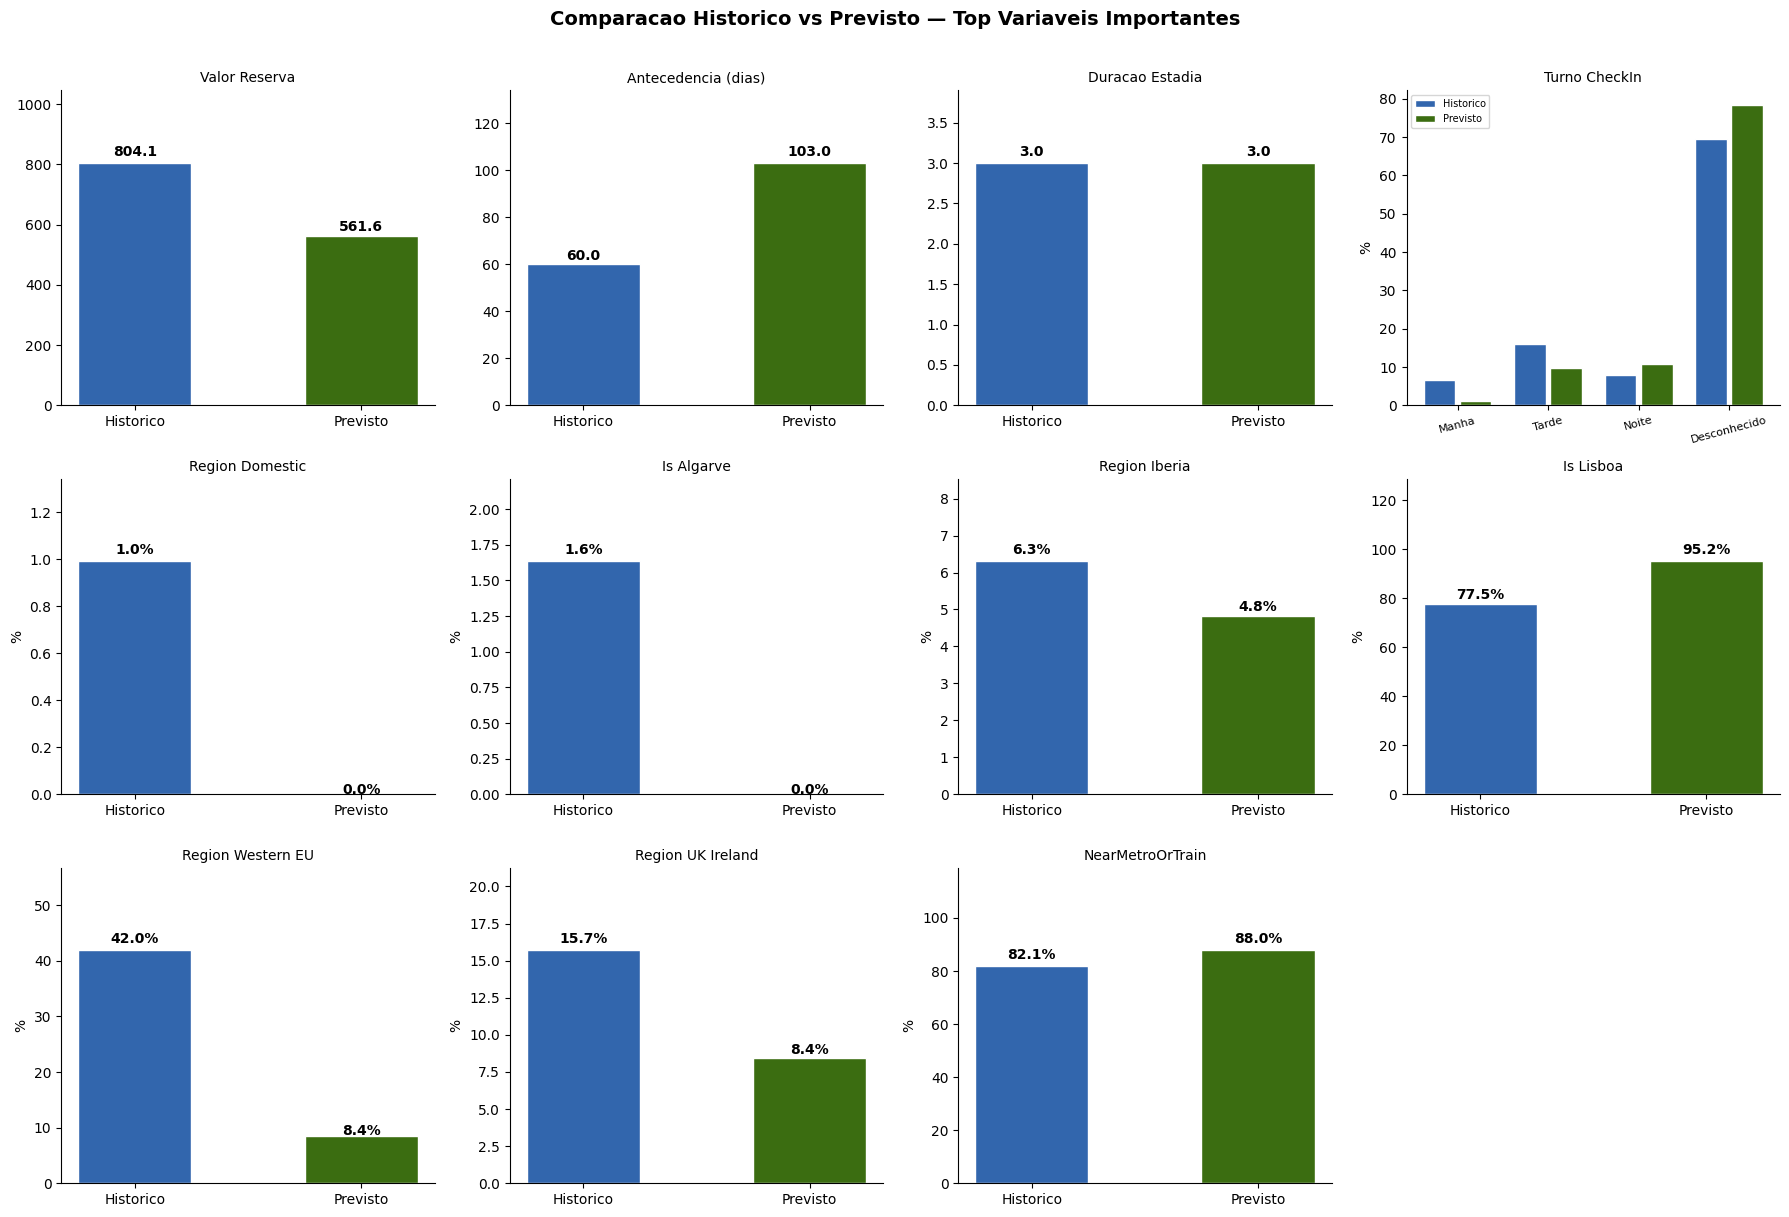

In [98]:
# @title Comparação de Perfil de Hóspedes — Histórico vs Previsto para Transfer
# ── Variáveis contínuas — comparar medianas ───────────────────────
vars_continuas  = ['ReservationValue', 'Antecedencia_dias', 'LenOfStay']
labels_continuas = ['Valor Reserva', 'Antecedencia (dias)', 'Duracao Estadia']

# ── Variáveis categóricas — comparar proporções ───────────────────
vars_categoricas  = ['Turno_CheckIn', 'Region_Domestic', 'Is_Algarve',
                     'Region_Iberia', 'Is_Lisboa', 'Region_Western_EU',
                     'Region_UK_Ireland', 'NearMetroOrTrain']

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Comparacao Historico vs Previsto — Top Variaveis Importantes",
             fontsize=14, fontweight='bold', y=1.01)

# ── Linha 1: variáveis contínuas ──────────────────────────────────
for i, (col, label) in enumerate(zip(vars_continuas, labels_continuas)):
    ax = fig.add_subplot(3, 4, i+1)
    med_hist = historico_transfer[col].median()
    med_novo = novos_transfer[col].median()

    bars = ax.bar(['Historico', 'Previsto'], [med_hist, med_novo],
                  color=['#3266ad', '#3B6D11'], width=0.5, edgecolor='white')
    for bar, val in zip(bars, [med_hist, med_novo]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.03,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=10, fontweight='500')
    ax.set_ylim(0, max(med_hist, med_novo) * 1.3)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# ── Linha 2 e 3: variáveis categóricas ───────────────────────────
for i, col in enumerate(vars_categoricas):
    ax = fig.add_subplot(3, 4, i+4)

    if col == 'Turno_CheckIn':
        categorias = ['Manha', 'Tarde', 'Noite', 'Desconhecido']
        hist_pct = historico_transfer[col].value_counts(normalize=True).reindex(categorias, fill_value=0) * 100
        novo_pct = novos_transfer[col].value_counts(normalize=True).reindex(categorias, fill_value=0) * 100

        x = np.arange(len(categorias))
        ax.bar(x - 0.2, hist_pct, width=0.35, color='#3266ad', label='Historico', edgecolor='white')
        ax.bar(x + 0.2, novo_pct, width=0.35, color='#3B6D11', label='Previsto',  edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(categorias, fontsize=8, rotation=15)
        ax.legend(fontsize=7)
    else:
        pct_hist = historico_transfer[col].mean() * 100
        pct_novo = novos_transfer[col].mean() * 100
        bars = ax.bar(['Historico', 'Previsto'], [pct_hist, pct_novo],
                      color=['#3266ad', '#3B6D11'], width=0.5, edgecolor='white')
        for bar, val in zip(bars, [pct_hist, pct_novo]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.03,
                    f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
        ax.set_ylim(0, max(pct_hist, pct_novo) * 1.35)

    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='500')
    ax.set_ylabel("%")
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [99]:
# @title Validação de IDs de NewReservations
ids_historico = set(df_reservations['ReservationId'].values)
ids_novos     = set(df_entrega['ReservationId'].values)

# Verificar se há IDs em comum (não devia haver — são reservas diferentes)
ids_comuns = ids_historico.intersection(ids_novos)
print(f"IDs em comum entre historico e novas reservas: {len(ids_comuns)}")

# Verificar se todos os IDs das novas reservas estão no ficheiro de entrega
ids_new_reservations = set(df_new_reservations['ReservationId'].values)
ids_entrega          = set(df_entrega['ReservationId'].values)

faltam = ids_new_reservations - ids_entrega
extra  = ids_entrega - ids_new_reservations

print(f"IDs nas NewReservations : {len(ids_new_reservations)}")
print(f"IDs no ficheiro entrega : {len(ids_entrega)}")
print(f"IDs em falta na entrega : {len(faltam)}")
print(f"IDs extra na entrega    : {len(extra)}")

IDs em comum entre historico e novas reservas: 108
IDs nas NewReservations : 393
IDs no ficheiro entrega : 393
IDs em falta na entrega : 0
IDs extra na entrega    : 0


In [100]:
# @title Validação Final de IDs de NewReservations
ids_new = set(df_new_reservations['ReservationId'].values)
ids_entrega = set(df_entrega['ReservationId'].values)

print(f"IDs nas NewReservations : {len(ids_new)}")
print(f"IDs no ficheiro entrega : {len(ids_entrega)}")
print(f"IDs em falta na entrega : {len(ids_new - ids_entrega)}")
print(f"IDs extra na entrega    : {len(ids_entrega - ids_new)}")
print(f"Full match?             : {ids_new == ids_entrega}")

IDs nas NewReservations : 393
IDs no ficheiro entrega : 393
IDs em falta na entrega : 0
IDs extra na entrega    : 0
Full match?             : True


# **Conclusão do Projeto**

Este projeto demonstrou que é possível construir um modelo preditivo robusto e generalizável para antecipar a propensão de hóspedes da Feels Like Home a adquirir o serviço de transfer. Partindo de dados históricos de reservas, apartamentos e transfers, foi desenvolvido um pipeline de preparação de dados capaz de tratar inconsistências, extrair variáveis com poder preditivo e garantir total reprodutibilidade, uma condição indispensável para que o modelo possa ser aplicado com segurança a dados futuros.

A construção dos modelos seguiu uma progressão deliberada de quatro soluções, dois XGBoost e dois GBT, com e sem regularização, cada uma informada pelas aprendizagens da anterior. Os primeiros dois modelos, sem regularização, revelaram overfitting expressivo, com gaps de FLH entre 8 e 13 pontos percentuais entre treino e teste. A introdução de regularização e de GridSearch nos modelos seguintes reduziu esses gaps para valores entre 3 e 4 pontos
percentuais, confirmando que a complexidade excessiva era o problema central e não a capacidade discriminativa do algoritmo em si, e baixando os gaps para menos 5 pontos percentuais.

O **XGBoost com regularização e GridSearch** emergiu como a melhor solução de toda a progressão. Com uma métrica de FLH de 0.772 no conjunto de teste e um gap de overfitting de apenas 3.2pp face ao treino (FLH treino: 0.804 vs FLH teste: 0.772), este modelo combina boa capacidade de discriminação com elevada confiança na generalização. A métrica FLH foi escolhida como critério central de avaliação precisamente porque pondera de forma equitativa a identificação de hóspedes com e sem transfer, penalizando o desequilíbrio de classes (92% sem transfer) de forma mais justa do que a accuracy tradicional, que seria facilmente inflacionada por um modelo que previsse sempre a classe maioritária.

Do ponto de vista do impacto operacional, o modelo entrega à Feels Like Home uma ferramenta concreta de segmentação, integrável no fluxo de comunicação pré-chegada. A cada novo conjunto de reservas, o pipeline pode ser executado na íntegra e produzir uma lista priorizada de hóspedes a contactar, reduzindo o esforço operacional, aumentando a taxa de conversão esperada e melhorando a experiência do cliente ao receber uma comunicação mais relevante e oportuna.

A próxima etapa natural seria monitorizar o desempenho do modelo em produção,
confrontar as previsões com os resultados reais e re-treinar periodicamente à medida que novos dados forem sendo acumulados.